## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Functions

In [2]:
def plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True):

    print("Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan")
    global model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan  

    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    
    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

    # FIT DATA
    # time-mask 4 fitting
    tmask = (t1_fit<g2[0])*(g2[0]<t2_fit)
    x, y, dy =  g2[0][tmask], g2[1][tmask], g2[2][tmask]
    
    # compute and save the fit
    fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
    g2fit.loc[0] = [Q_notebook, dQ_notebook,
                    fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                    fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                    fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                    fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                    fit.redchi,]
    if save: g2fit.to_csv(f"{g2fit4damaged_vGeO2_folder}g2fit-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", index=False)
    
    # print fit report
    display(g2fit)

    # PLOT FIT AND RESIDUALS IN SUBPLOTS
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}, sharex=True)

    # Main fit plot
    ax1.scatter(g2[0], g2[1], s=1, c='C0')
    t_mt, g2_mt, dg2_mt = XPCS.get_g2mt_fromling2(itime, g2[1], g2[2])
    ax1.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt = 'o', c='C1')

    xfit = np.arange(np.min(g2[0]), np.max(g2[0]), 1e-2)
    yfit = fit.eval(t=xfit)
    ax1.plot(xfit, yfit, c='black', linestyle='--')
    if t1_fit != 0:
        ax1.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit != 1e100:
        ax1.axvline(t2_fit, color='red', linestyle='--')
    ax1.set_ylabel('g2')
    ax1.set_xscale('log')
    ax1.set_ylim(bottom=1, top=np.max(g2[1] + g2[2]))

    # Residuals plot
    residuals = (g2[1] - fit.eval(t=g2[0])) / g2[2]
    ax2.scatter(g2[0], residuals, color='C0')
    ax2.axhline(0, color='black', linestyle='--')
    ax2.set_xlabel('t [s]')
    ax2.set_ylabel('Res/$\\sigma$')
    ax2.set_xscale('log')

    plt.setp(ax1.get_xticklabels(), visible=False)

    return fig, ax1, ax2


### Load masks

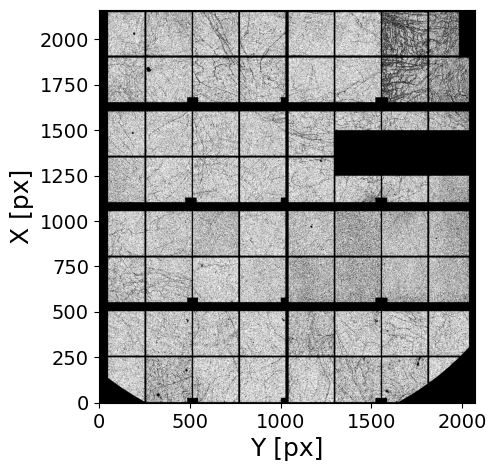

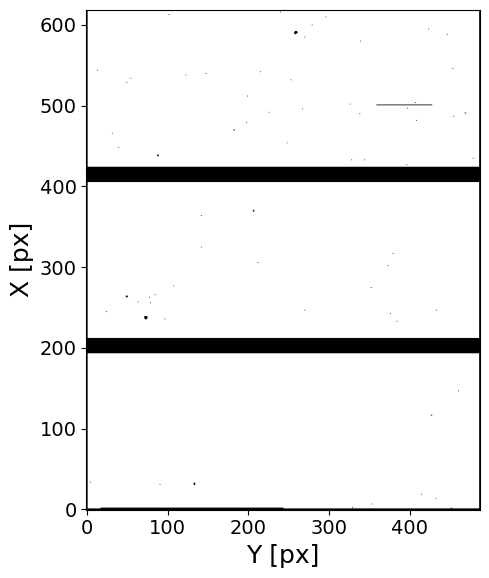

In [3]:
### MASKS
e4m_htmask_GeO2_7_30C  = np.load(MASKS_folder+'e4m_htmask-GeO2_7_30C_0003_0003' +'.npy')
e4m_htmask_GeO2_7_100C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_100C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_170C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_170C_0001_0003'+'.npy')
e4m_htmask_GeO2_7_240C = np.load(MASKS_folder+'e4m_htmask-GeO2_7_240C_0001_0003'+'.npy')
e4m_htmask = e4m_htmask_GeO2_7_30C * e4m_htmask_GeO2_7_100C * e4m_htmask_GeO2_7_170C * e4m_htmask_GeO2_7_240C

e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask*e4m_htmask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

### pilatus MASKS
pilatus_mask = np.load(MASKS_folder+'pilatus300k_mask_20240201'+'.npy').astype(bool)

plt.figure(figsize=(6, 6))
plt.imshow(~pilatus_mask, cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.tight_layout(); plt.show()

### Beamstop mask

In [4]:
#######################################
sample_name = 'GeO2_7_30C'
Ndataset = 3
Nscan = 3
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 0.05 s)
Concatenating vectors ...
Done! (elapsed time = 0.01 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_7_30C/GeO2_7_30C_0003/scan0003/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     1.5e-04
	 | Memory usage (scipy.csr_array): 0.007 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 242.0
# of pixels above Ith_high treshold ->  610960 pixels (of 4471016 => 13.66 %)
################################################################################



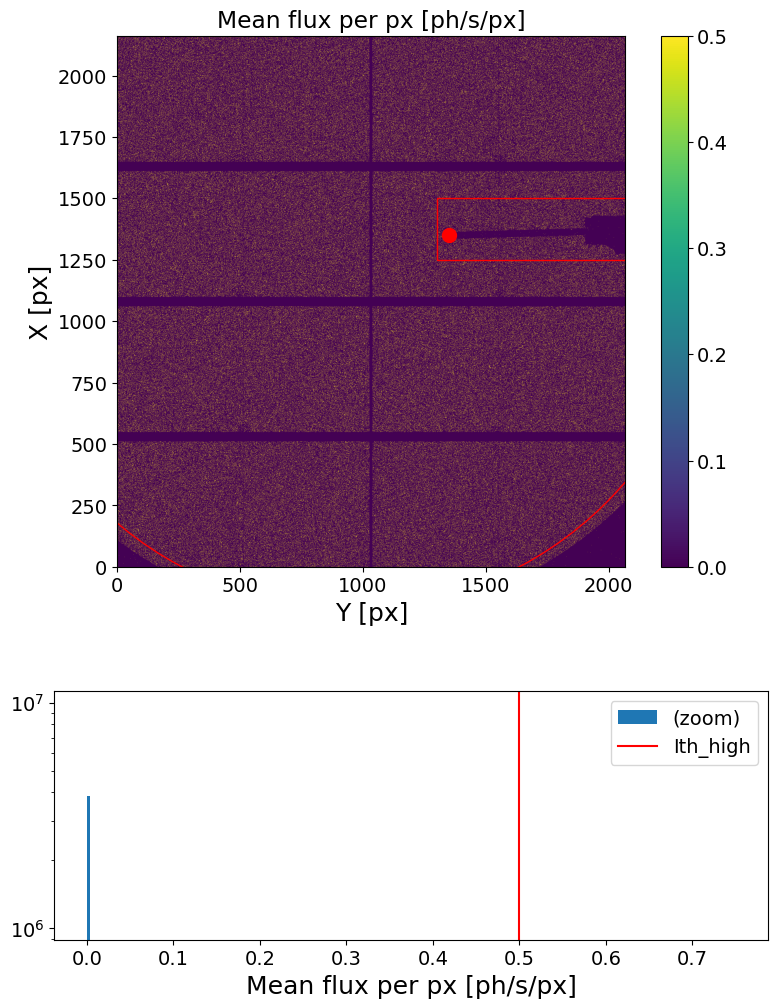

In [5]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.5, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



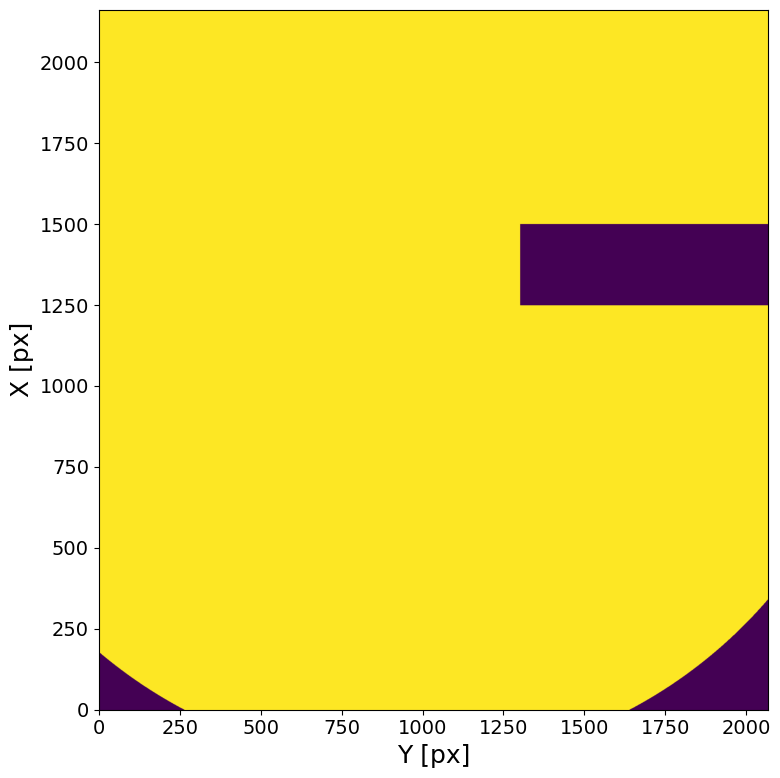

In [6]:
bs_mask = XPCS.gen_mask(mask_geom=geom)

### Q mask

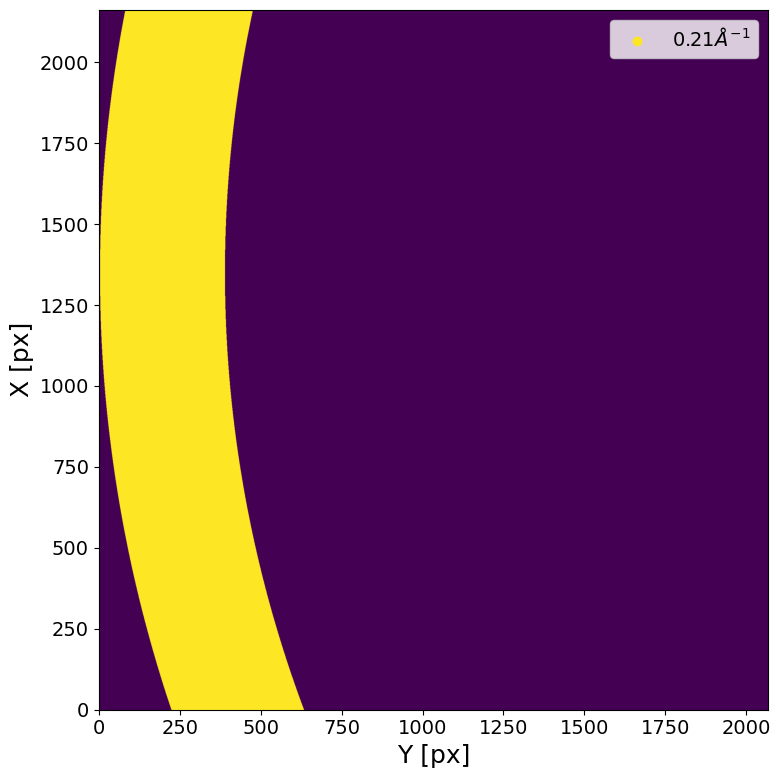

In [7]:
###################
Q_notebook = .21 # [.21, .19, .17, .15, .13]
dQ_notebook = .01 # => Q_width = 2*dQ
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Q_notebook, dQ_notebook, Qmap_plot=False)

### htmask killed pixels ?

In [8]:
print(f'Percentage of kept pixel by e4m_htmask_GeO2_7_30C:  {round((bs_mask*Qmask*e4m_mask*e4m_htmask_GeO2_7_30C).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')
print(f'Percentage of kept pixel by e4m_htmask_GeO2_7_100C: {round((bs_mask*Qmask*e4m_mask*e4m_htmask_GeO2_7_100C).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')
print(f'Percentage of kept pixel by e4m_htmask_GeO2_7_170C: {round((bs_mask*Qmask*e4m_mask*e4m_htmask_GeO2_7_170C).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')
print(f'Percentage of kept pixel by e4m_htmask_GeO2_7_240C: {round((bs_mask*Qmask*e4m_mask*e4m_htmask_GeO2_7_240C).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')

print(f'Percentage of kept pixel by e4m_htmask:             {round((bs_mask*Qmask*e4m_mask*e4m_htmask).sum() / (bs_mask*Qmask*e4m_mask).sum()*100,2)}%')

Percentage of kept pixel by e4m_htmask_GeO2_7_30C:  88.66%
Percentage of kept pixel by e4m_htmask_GeO2_7_100C: 91.55%
Percentage of kept pixel by e4m_htmask_GeO2_7_170C: 87.1%
Percentage of kept pixel by e4m_htmask_GeO2_7_240C: 94.27%
Percentage of kept pixel by e4m_htmask:             74.28%


# Alligment

## XPCS scan: [Alligment] T=30C, Q=0.19, 3min@200ms (1002fm) (GeO2_6, dataset 1, scan 7)

In [39]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan = 7
Nfi, Nff = 1, None # skip beamstop opening
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.2 1 1002
Ei = 9.699998837562536
itime = 0.200112
theta = 1.7500000000000004
Q = 0.15
T = 3.34 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 5.41 s)
Concatenating vectors ...
Done! (elapsed time = 0.07 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6/GeO2_6_0001/scan0007/
	 | Shape:       (1001, 523950)
	 | Sparsity:     3.9e-02
	 | Memory usage (scipy.csr_array): 0.227 GB (np.array usage: 1.954 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.06 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 0.13 s)


### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



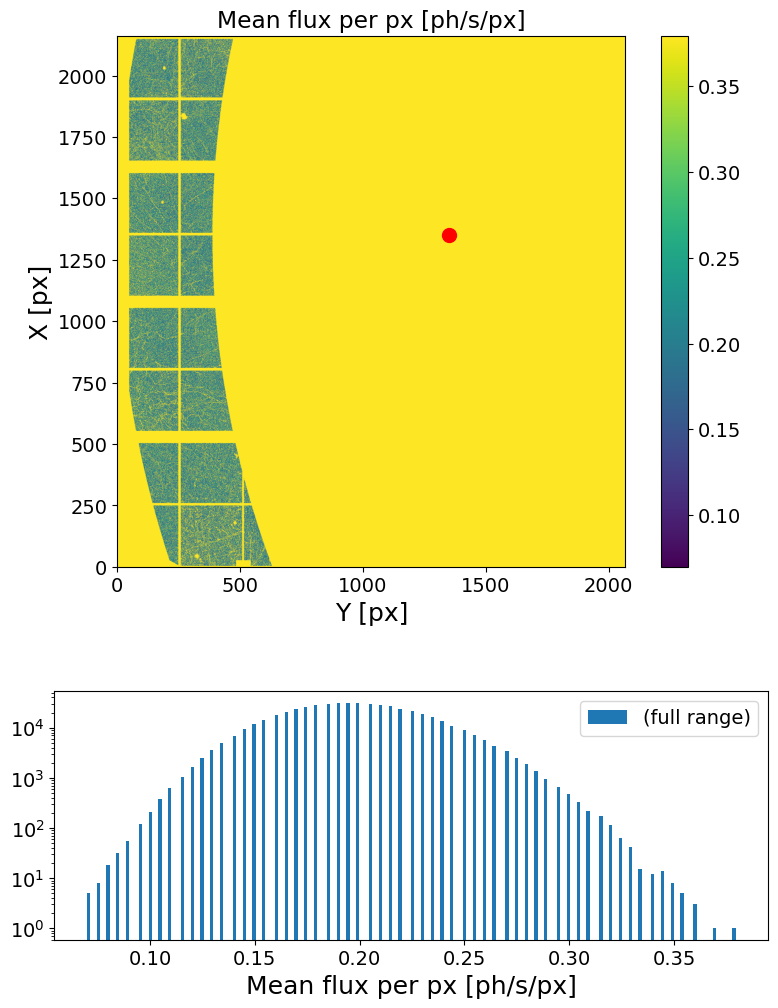

In [40]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [41]:
####################
Lbin = 1
Nstep = 1
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
#np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

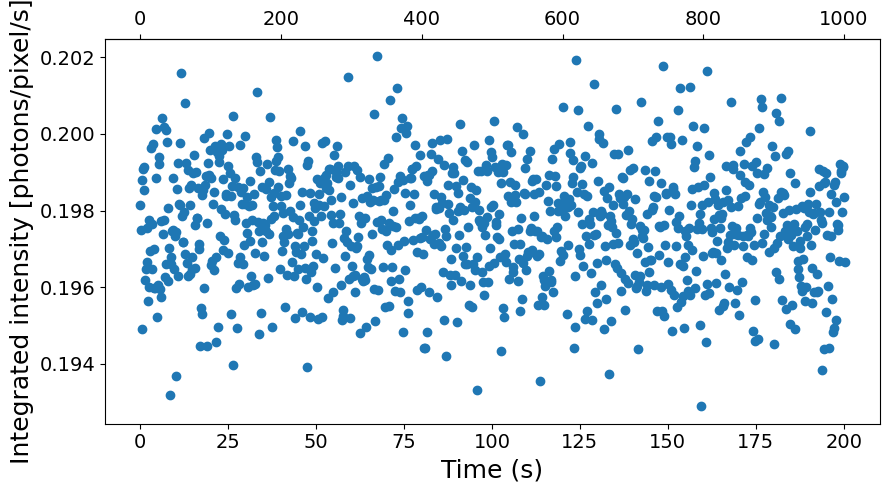

In [42]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

## XPCS scan: [Alligment] T=30C, Q=0.19, 20min @ 200ms (6000fm) @ damaged point (GeO2_6, dataset 1, scan 8)
Trying to understend the best itime (still didn't know we can go at full spid).

In [43]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan = 8
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.2 1 6000
Ei = 9.699998837562536
itime = 0.200112
theta = 1.7500000000000004
Q = 0.15
T = 20.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/2 loops)


	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/2 loops)
Done! (elapsed time = 31.04 s)
Concatenating vectors ...
Done! (elapsed time = 0.45 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6/GeO2_6_0001/scan0008/
	 | Shape:       (5999, 523950)
	 | Sparsity:     3.9e-02
	 | Memory usage (scipy.csr_array): 1.359 GB (np.array usage: 11.709 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.54 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 0.86 s)


### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



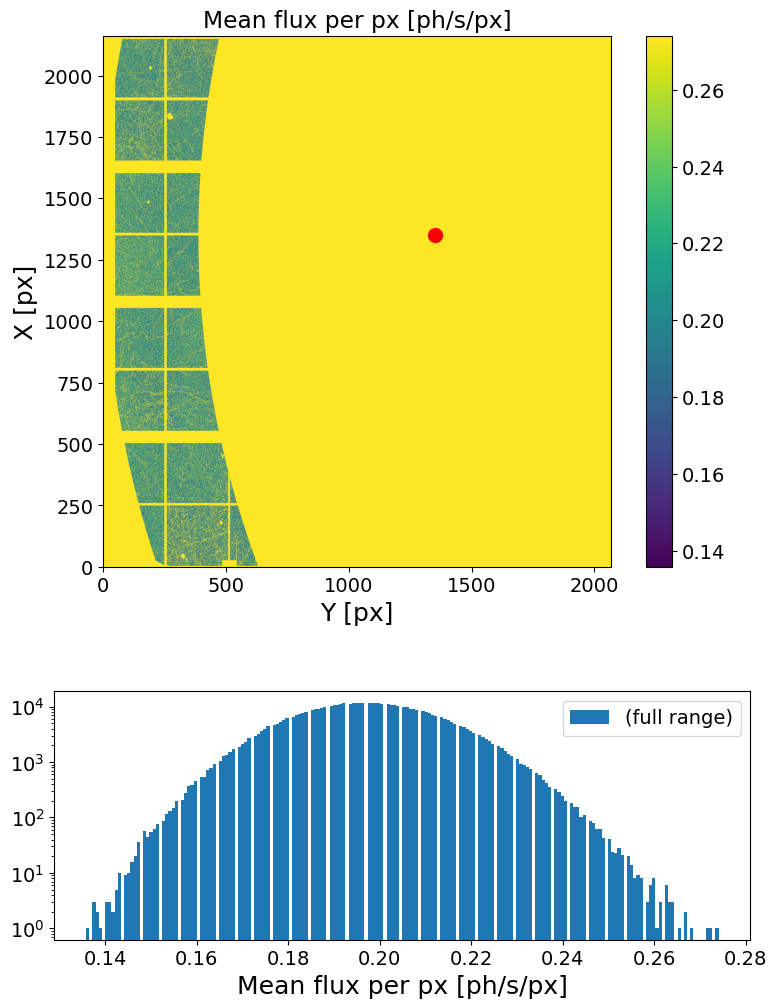

In [44]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [45]:
####################
Lbin = 10
Nstep = 10
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
#np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

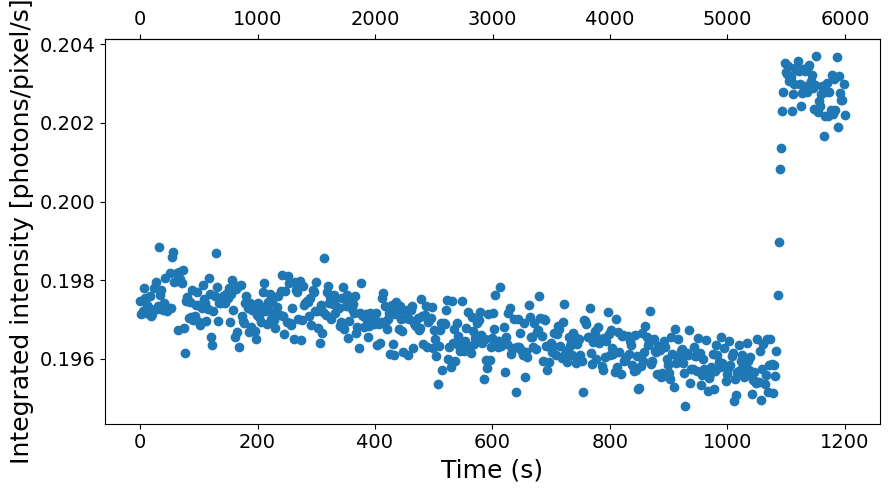

In [46]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Linear correlation of damaged-vGeO2

In [47]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=5000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
#np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.13 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 0.97 s)
	 | 999 X 999 squared matrix
	 | memory usage (np.array @ float32) = 0.004 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 0.01 s)

Computing g2 (using cython code)...
Done! (elapsed time = 0.0 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,4.865157,0.286009,5.878713,0.720882,0.030222,4.192386,0.033822,0.001169,3.455801,1.001179,0.000065,0.006502,0.998611


/tmp/ipykernel_490053/4212458604.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


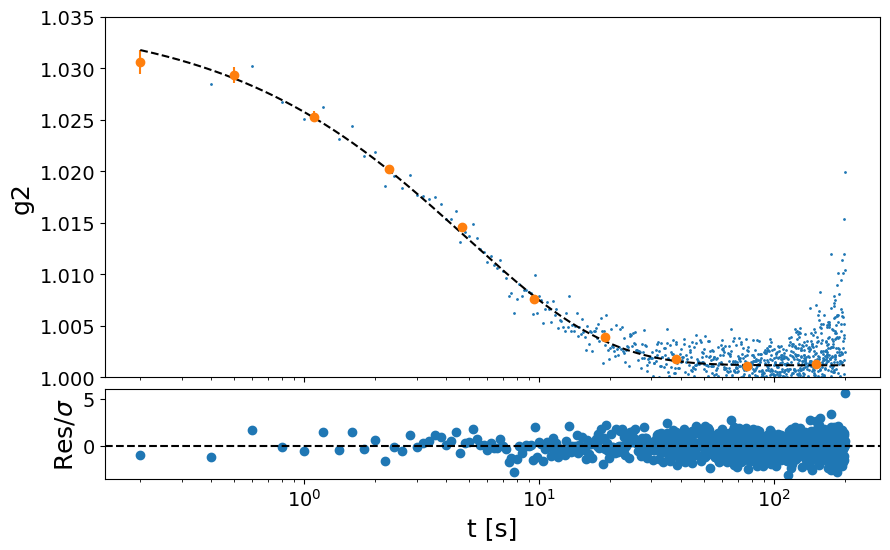

In [48]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# First scans @ room T

## XPCS scan: T=30 C, Q=0.19, 20min @ 20ms ON **damaged point** (GeO2_6, dataset 1, scan 9)

In [9]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan = 9
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

#e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
#e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################



### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



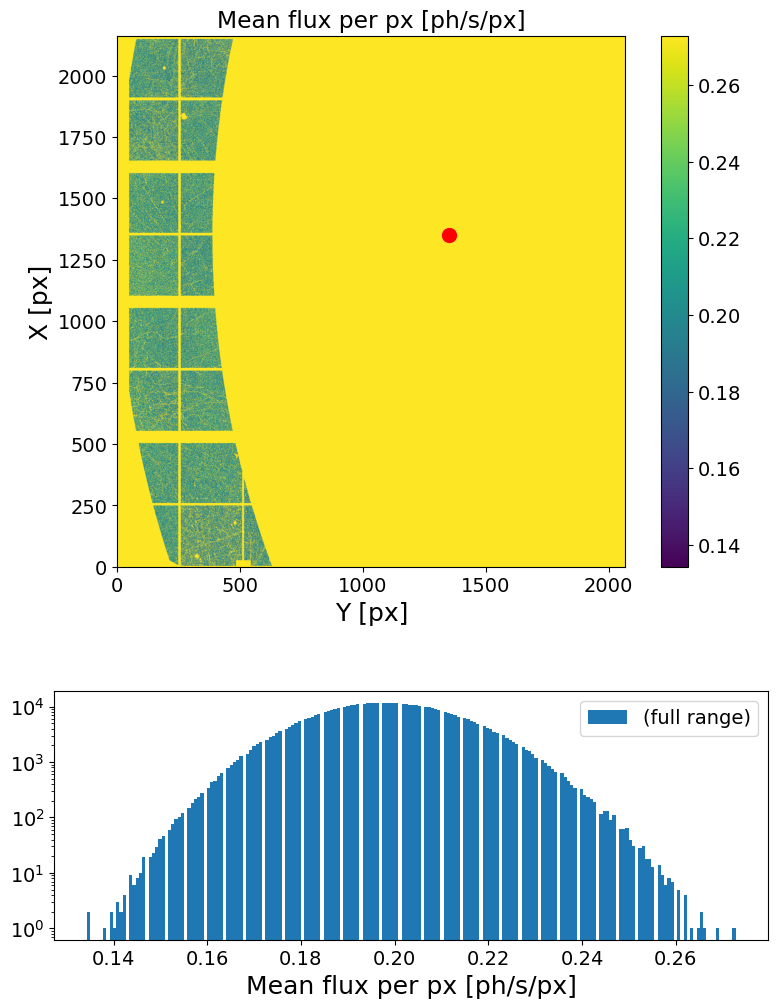

In [146]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [149]:
####################
Lbin = 10
Nstep = 10
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

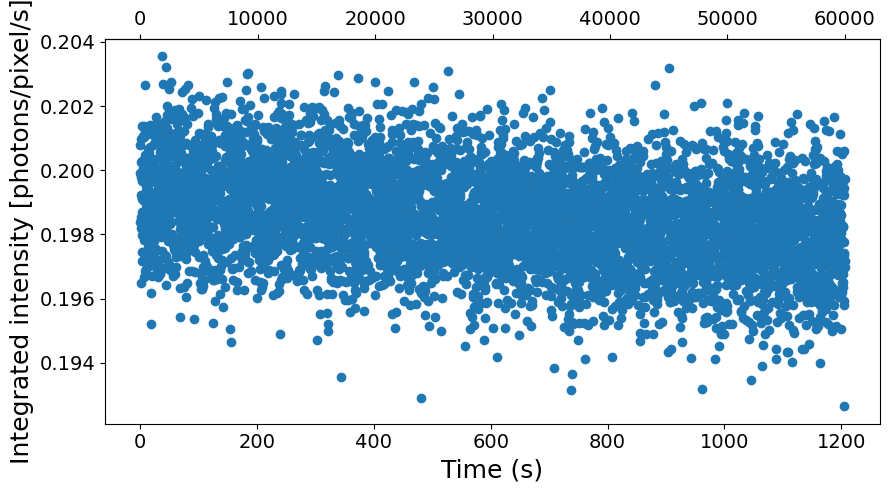

In [150]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

### Linear correlation of damaged-vGeO2

In [53]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=None, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.0 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 11.52 s)
	 | 59999 X 59999 squared matrix
	 | memory usage (np.array @ float32) = 13.411 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.59 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.82 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,4.9945,0.101147,2.025166,0.740181,0.010585,1.430085,0.033097,0.000381,1.152386,1.001131,0.000009,0.00085,0.997517


/tmp/ipykernel_490053/3916755815.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


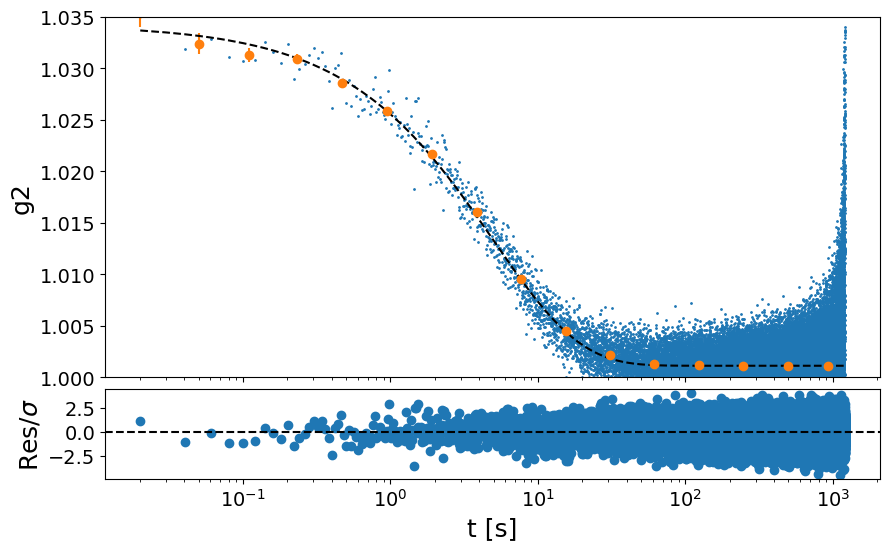

In [54]:
##################
t1_fit = 0
t2_fit = 1e100
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

## XPCS scan: [Test on fresh p] T=30C, Q=0.19, 5min @ 20ms ON **fresh point** (GeO2_6, dataset 1, scan 11)
Test for going down in itime (still didn't know we can go at full spid)...

In [55]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan =11
Nfi, Nff = 1, None
mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 15000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 5.03 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/3 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/3 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/3 loops)
Done! (elapsed time = 9.64 s)
Concatenating vectors ...
Done! (elapsed time = 0.1 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6/GeO2_6_0001/scan0011/
	 | Shape:       (14999, 523950)
	 | Sparsity:     4.1e-03
	 | Memory usage (scipy.csr_array): 0.357 GB (np.array usage: 29.276 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.1 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 0.2 s)


### Flux check

In [56]:
#XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [57]:
####################
Lbin = 10
Nstep = 10
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

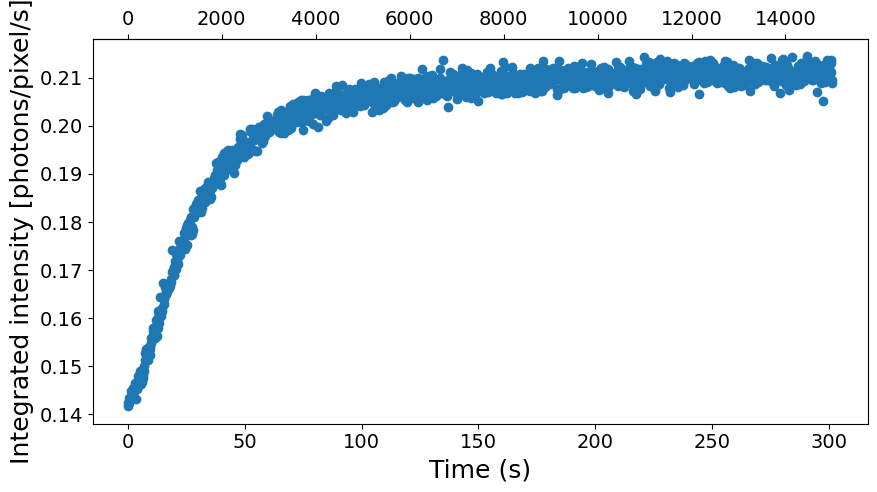

In [58]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))

# XPCS scan: T=30C, Q=0.19, 75min @ 20ms ON damaged point (GeO2_6, dataset 1, scan 12)
Start the Temperature ramp!

In [11]:
#######################################
sample_name = 'GeO2_6'
Ndataset = 1
Nscan =12
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 220000
Ei = 9.699998837562536
itime = 0.0201
theta = 1.7500000000000004
Q = 0.15
T = 73.70 min
#############################



### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



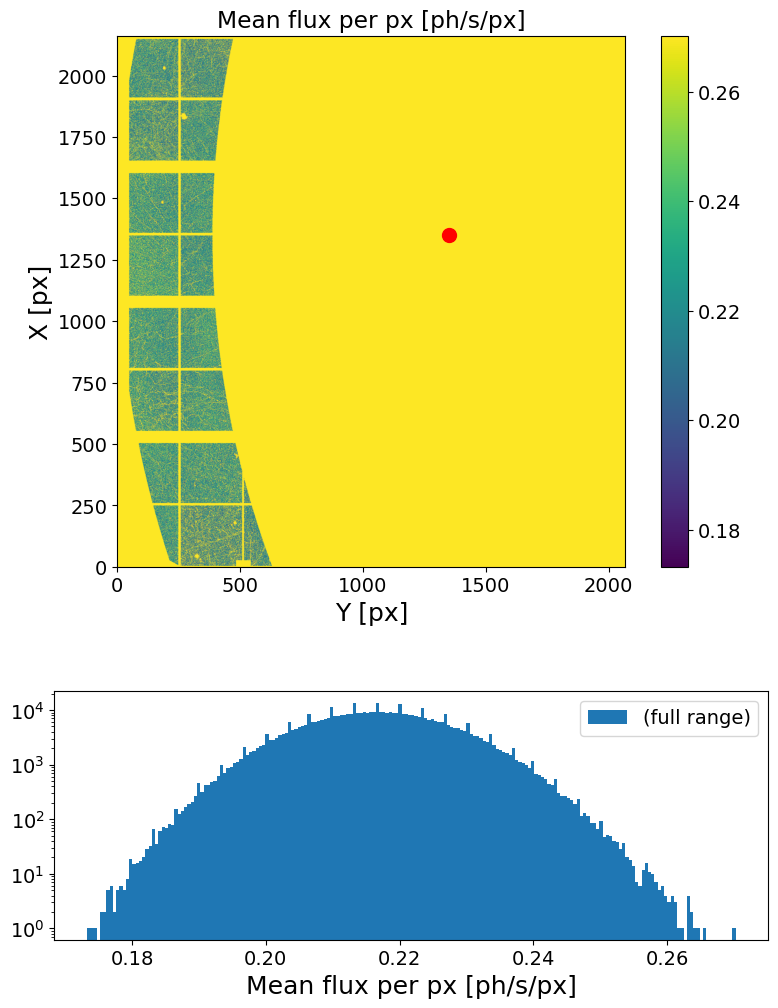

In [60]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [61]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

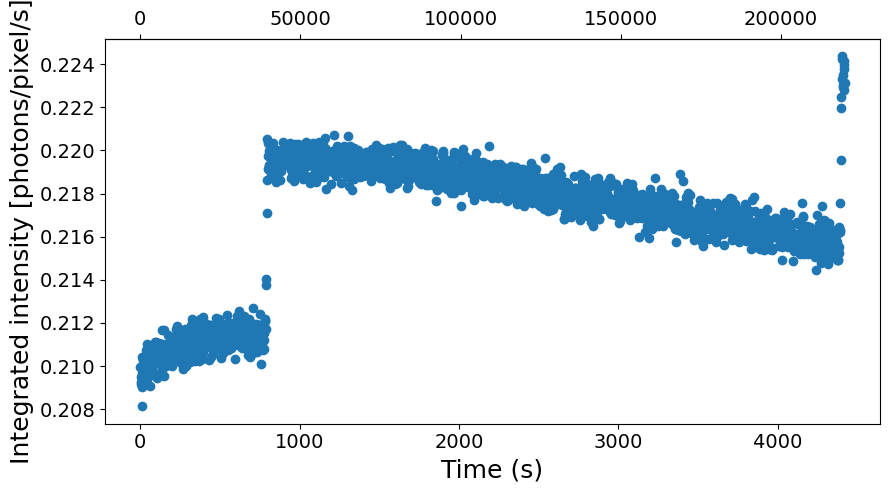

In [62]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [63]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=100000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 3.35 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 36.51 s)
	 | 119999 X 119999 squared matrix
	 | memory usage (np.array @ float32) = 53.643 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 6.34 s)

Computing g2 (using cython code)...
Done! (elapsed time = 13.72 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,5.25685,0.073178,1.392058,0.741659,0.007271,0.980349,0.030235,0.000239,0.791379,1.001154,0.000004,0.000382,1.004


/tmp/ipykernel_490053/1096979051.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


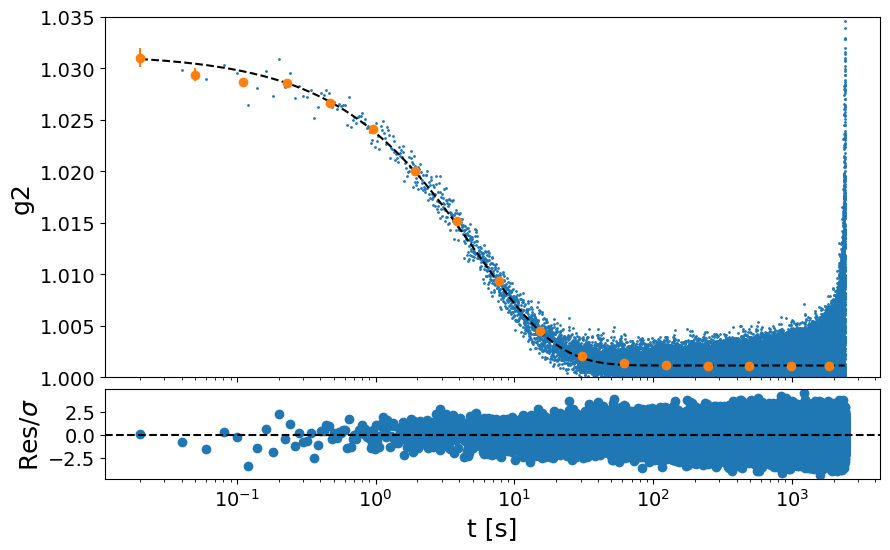

In [64]:
##################
t1_fit = None
t2_fit = None
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=100C, Q=0.19, 20min @ 20ms (GeO2_6, dataset 1, scan 3)

In [65]:
#######################################
sample_name = 'GeO2_6_100C'
Ndataset = 1
Nscan =3
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



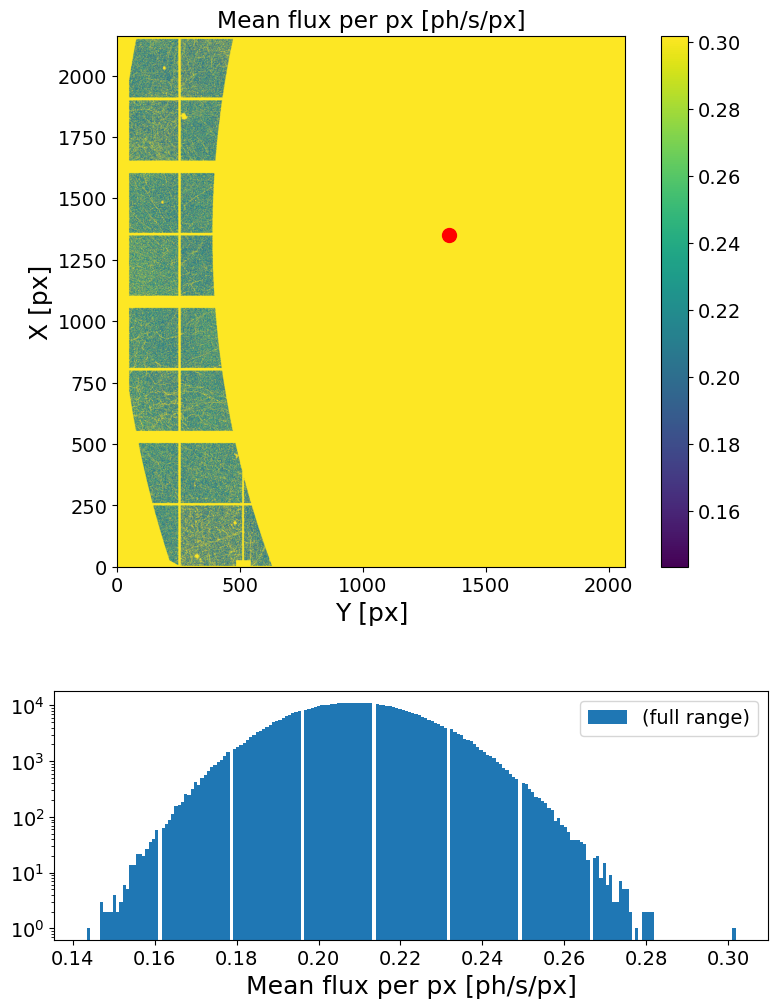

In [66]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [67]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

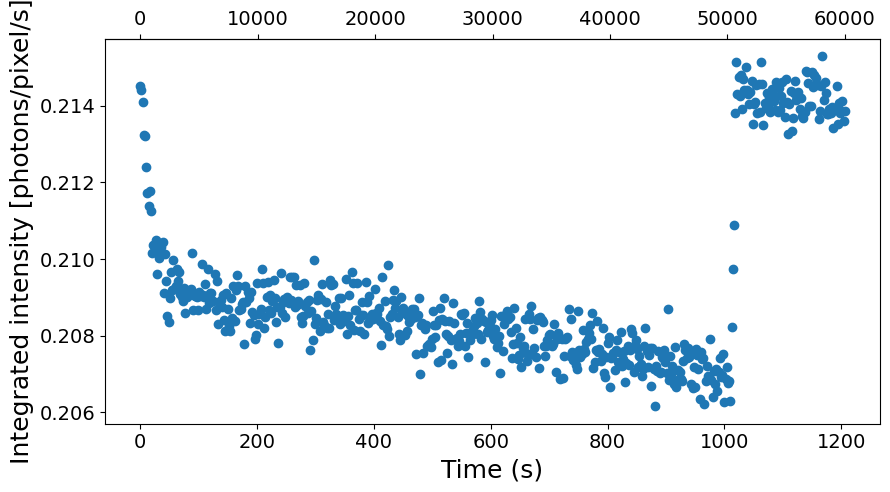

In [68]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [69]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=10000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 1.14 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 13.07 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.26 s)

Computing g2 (using cython code)...
Done! (elapsed time = 1.98 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,4.800453,0.121648,2.534088,0.724006,0.012627,1.743984,0.028888,0.000411,1.424277,1.001178,0.000012,0.001151,0.992864


/tmp/ipykernel_490053/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


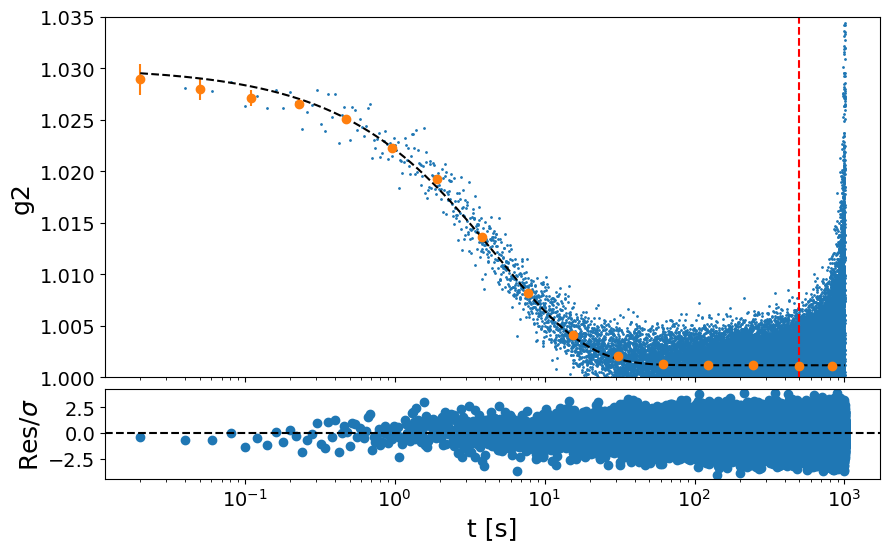

In [70]:
##################
t1_fit = None
t2_fit = 5e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=170C, Q=0.19, 20min @ 20ms (GeO2_6, dataset 1, scan 1) 

In [71]:
#######################################
sample_name = 'GeO2_6_170C'
Ndataset = 1
Nscan = 1
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

Done! (elapsed time = 16.5 s)
Concatenating vectors ...
Done! (elapsed time = 0.55 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6_170C/GeO2_6_170C_0001/scan0001/
	 | Shape:       (59999, 523950)
	 | Sparsity:     4.1e-03
	 | Memory usage (scipy.csr_array): 1.448 GB (np.array usage: 117.110 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.74 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.25 s)


### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



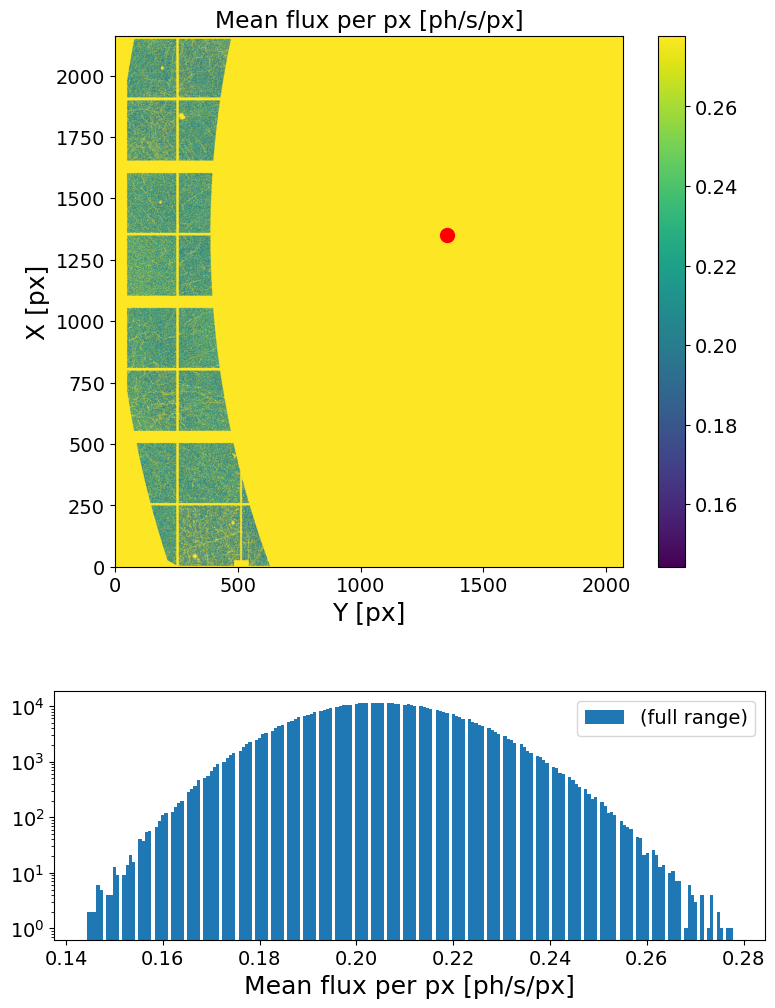

In [72]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [73]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

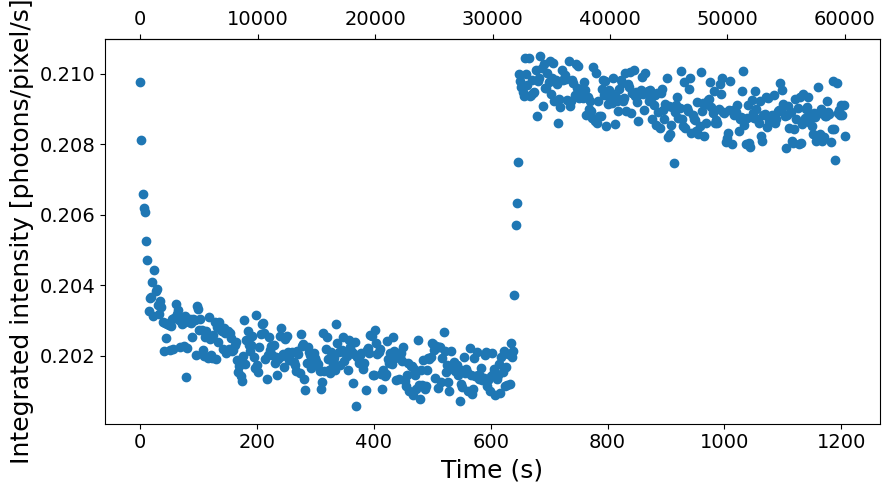

In [74]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [75]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=10000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 1.29 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 13.05 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.23 s)

Computing g2 (using cython code)...
Done! (elapsed time = 1.98 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,4.275126,0.11816,2.763893,0.746953,0.014842,1.986993,0.027194,0.000431,1.585289,1.00118,0.000011,0.001148,0.986434


/tmp/ipykernel_490053/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


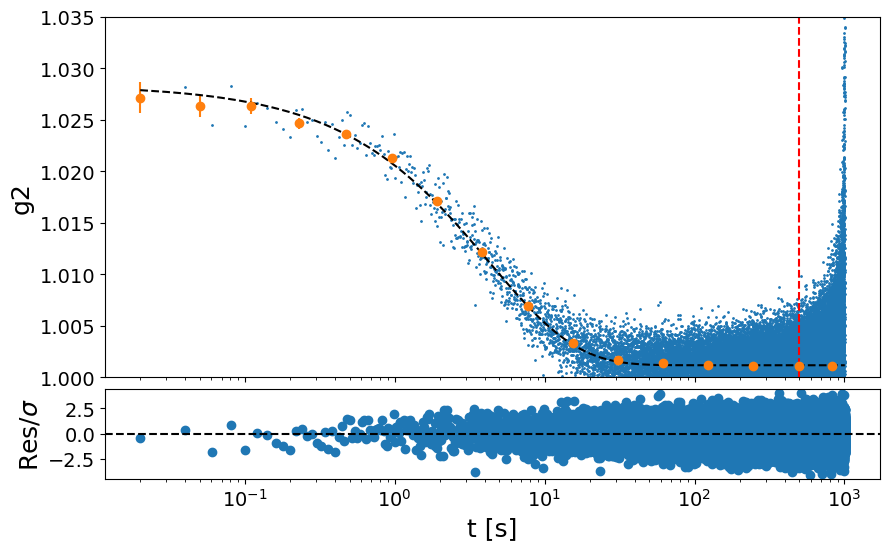

In [76]:
##################
t1_fit = None
t2_fit = 5e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=240C , Q=0.19, 20min @ 20ms (GeO2_6, dataset 1, scan 1)

In [77]:
#######################################
sample_name = 'GeO2_6_240C'
Ndataset = 1
Nscan = 3
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 3.0
################################################################################



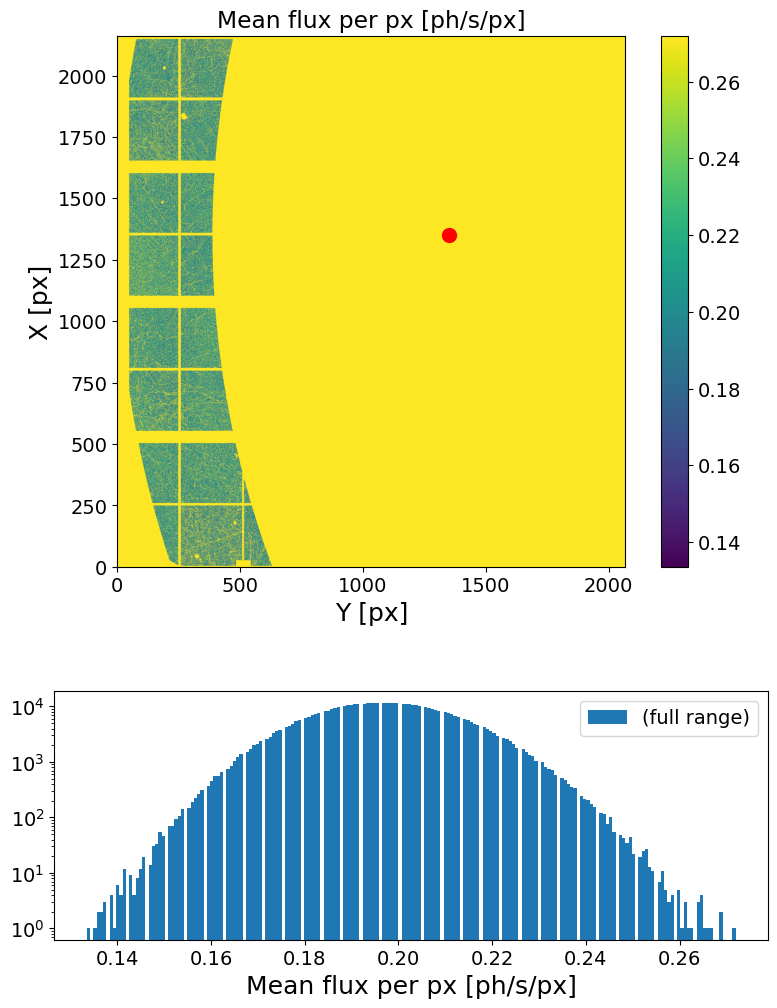

In [78]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [79]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

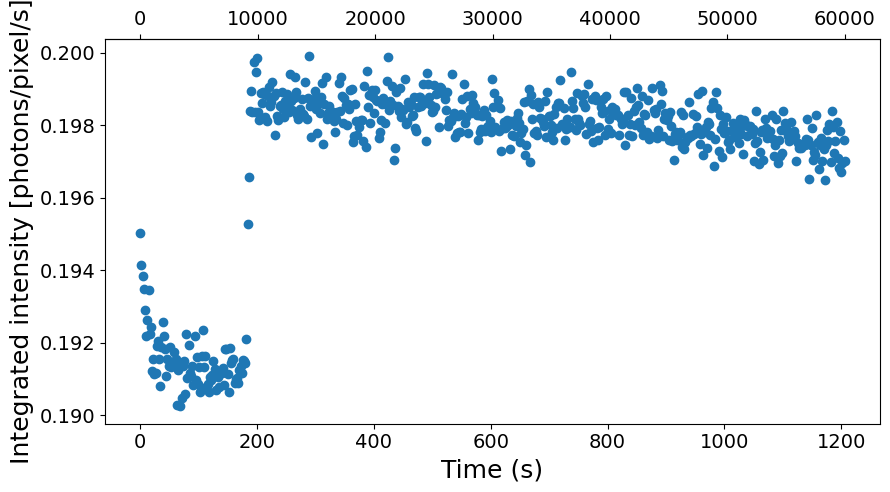

In [80]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [81]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=10000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 1.18 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 11.6 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.26 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.11 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,3.695633,0.120803,3.268795,0.739431,0.017978,2.431345,0.026653,0.000509,1.90841,1.001346,0.000029,0.002872,1.012466


/tmp/ipykernel_490053/3862425413.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


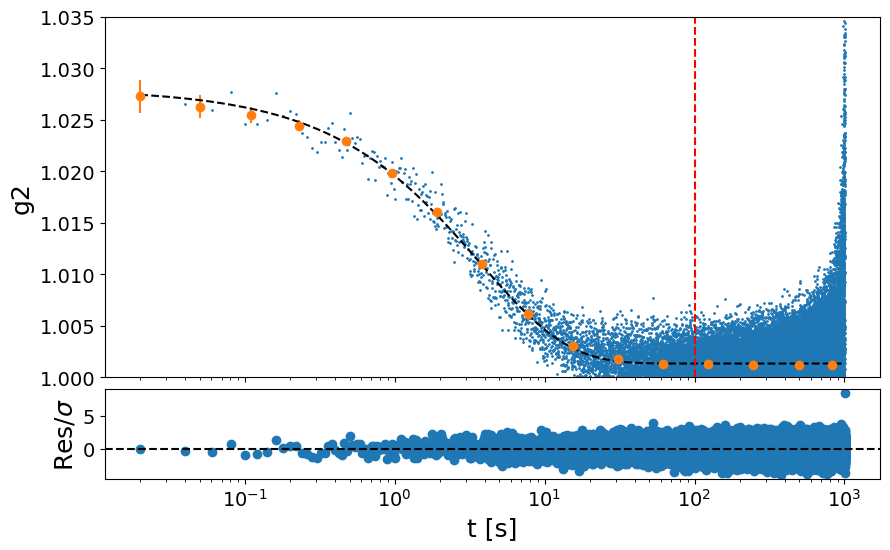

In [82]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=310C, Q=0.19, 20min @ 20ms (GeO2_6, dataset 1, scan 1) 

In [ ]:
#######################################
sample_name = 'GeO2_6_310C'
Ndataset = 1
Nscan = 3
Nfi, Nff = None, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



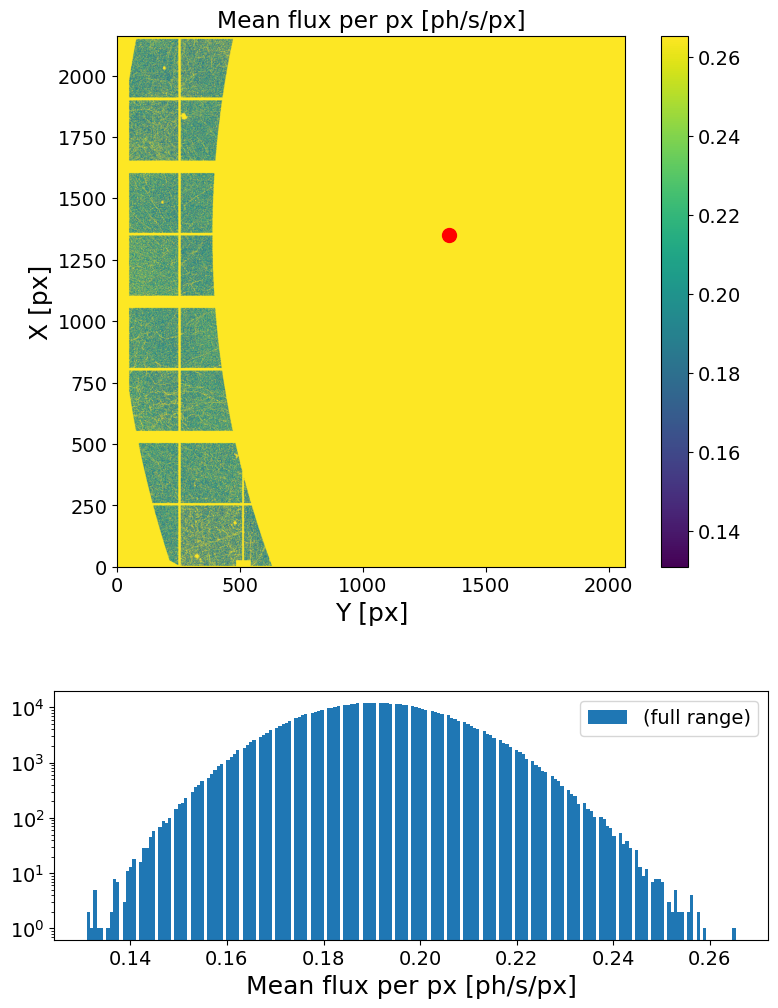

In [84]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [85]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

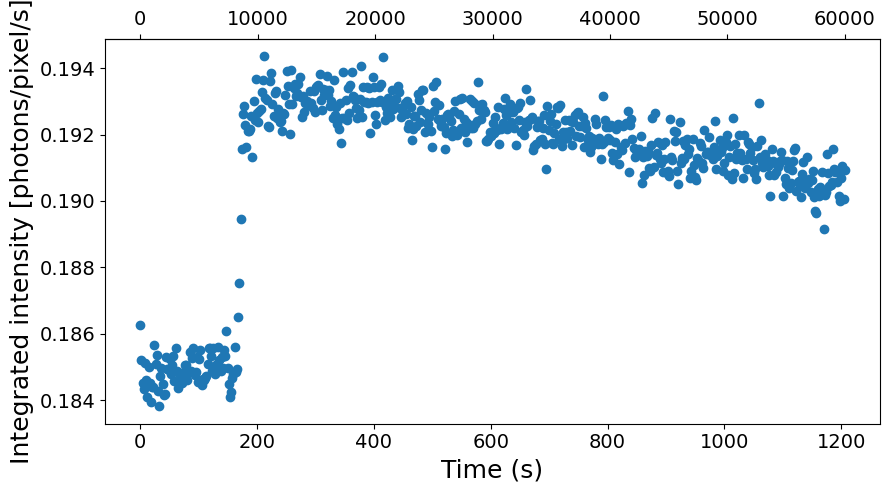

In [86]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 1.13 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 11.93 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.12 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.12 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,3.034946,0.117683,3.877605,0.722372,0.019031,2.634449,0.026256,0.00057,2.172392,1.001187,0.000012,0.001228,1.005986


/tmp/ipykernel_490053/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


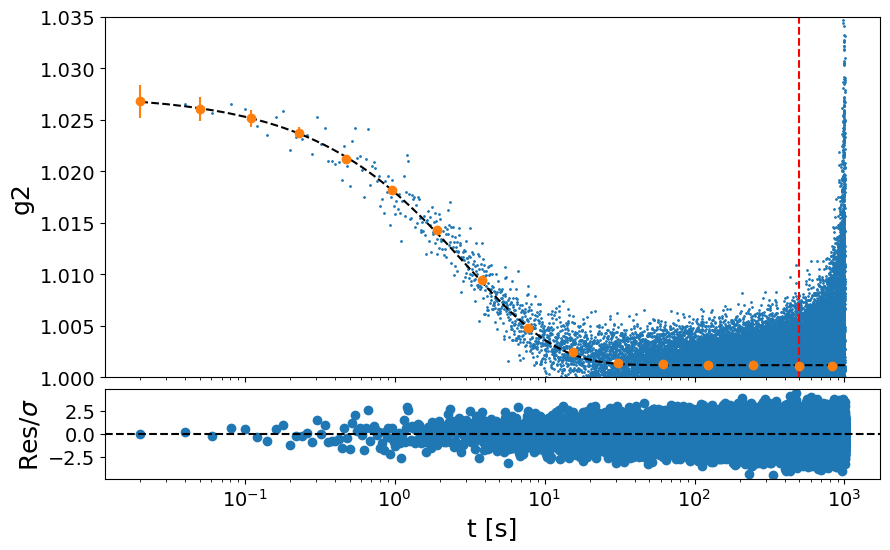

In [88]:
##################
t1_fit = None
t2_fit = 5e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

#  XPCS scan: T=380C, Q=0.19, 20min@20ms (GeO2_6, dataset 1, scan 1)

In [89]:
#######################################
sample_name = 'GeO2_6_380C'
Ndataset = 1
Nscan = 1
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

Done! (elapsed time = 15.36 s)
Concatenating vectors ...
Done! (elapsed time = 0.64 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6_380C/GeO2_6_380C_0001/scan0001/
	 | Shape:       (59999, 523950)
	 | Sparsity:     3.7e-03
	 | Memory usage (scipy.csr_array): 1.316 GB (np.array usage: 117.110 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.74 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.17 s)


### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



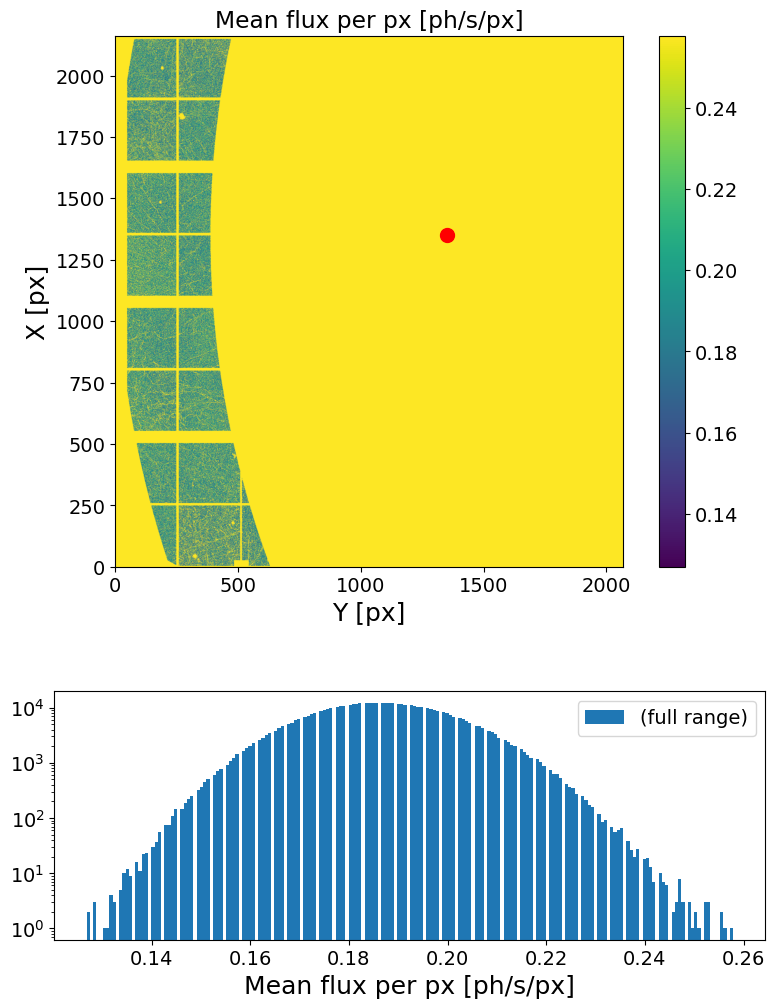

In [90]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [91]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

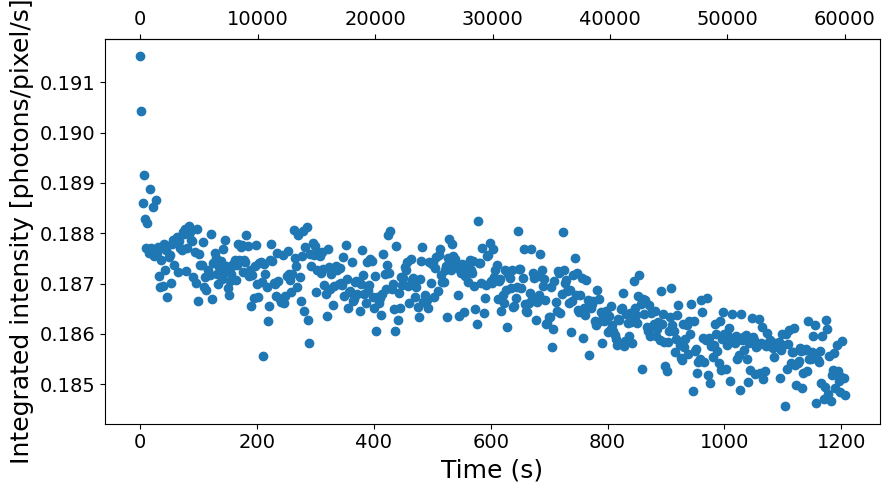

In [92]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 1.22 s)
Computing G2t (using MKL library)...


Done! (elapsed time = 11.69 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.03 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.0 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,2.095549,0.109647,5.232388,0.702291,0.023789,3.387283,0.025195,0.000724,2.875386,1.001185,0.000012,0.001246,0.998233


/tmp/ipykernel_490053/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


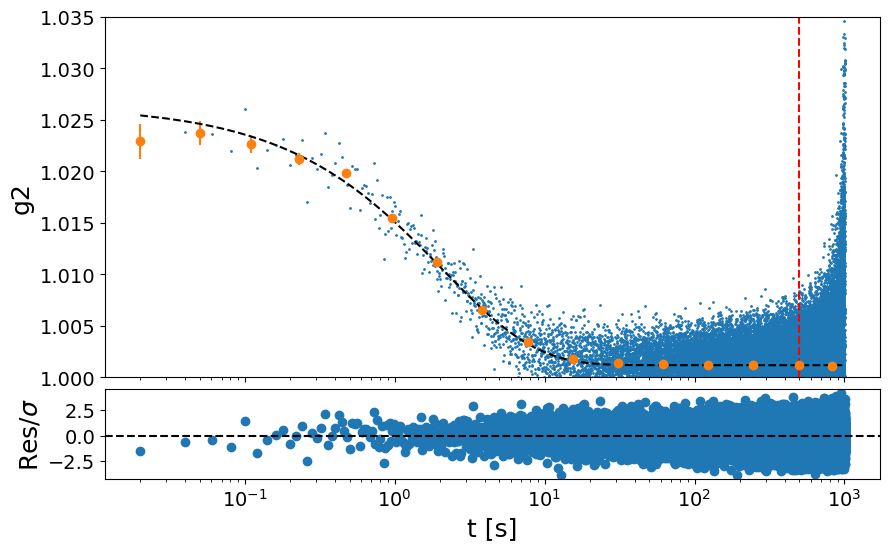

In [94]:
##################
t1_fit = None
t2_fit = 5e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

#  XPCS scan:T=450 C, Q=0.19, 20min @ 20ms (60000fm) (GeO2_6, dataset 1, scan 1)

In [95]:
#######################################
sample_name = 'GeO2_6_450C'
Ndataset = 1
Nscan = 3
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

Done! (elapsed time = 13.74 s)
Concatenating vectors ...
Done! (elapsed time = 0.45 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6_450C/GeO2_6_450C_0001/scan0003/
	 | Shape:       (59999, 523950)
	 | Sparsity:     3.5e-03
	 | Memory usage (scipy.csr_array): 1.233 GB (np.array usage: 117.110 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.62 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.06 s)


### Flux check

################################################################################
Maximum count in the whole run -> 3.0
################################################################################



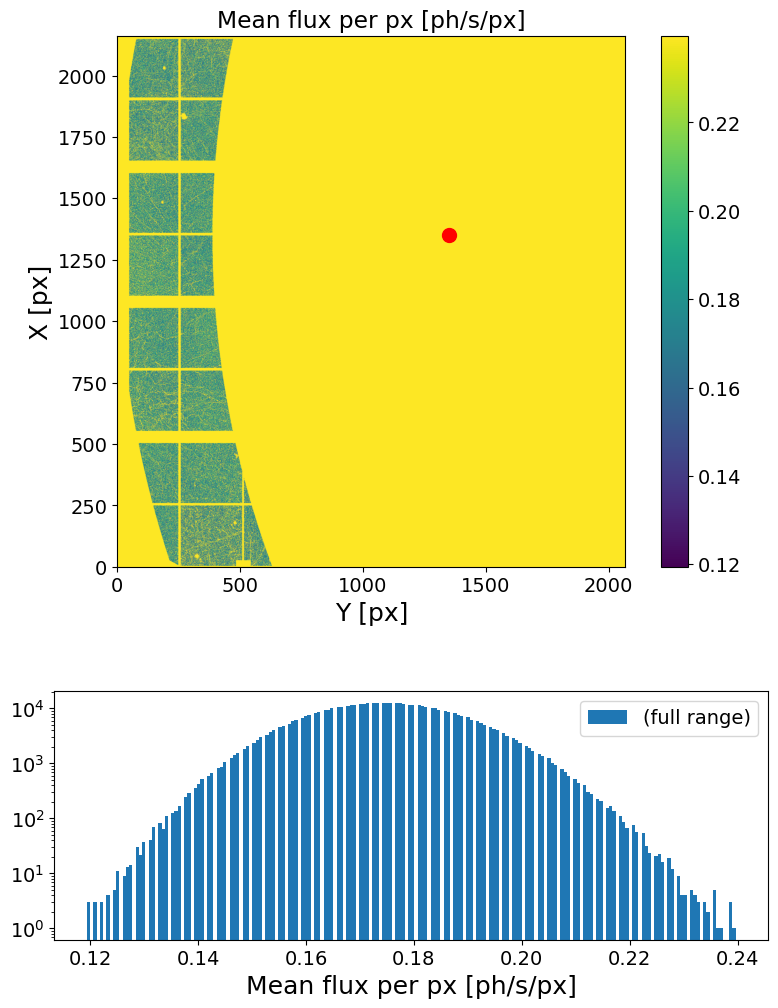

In [96]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [97]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

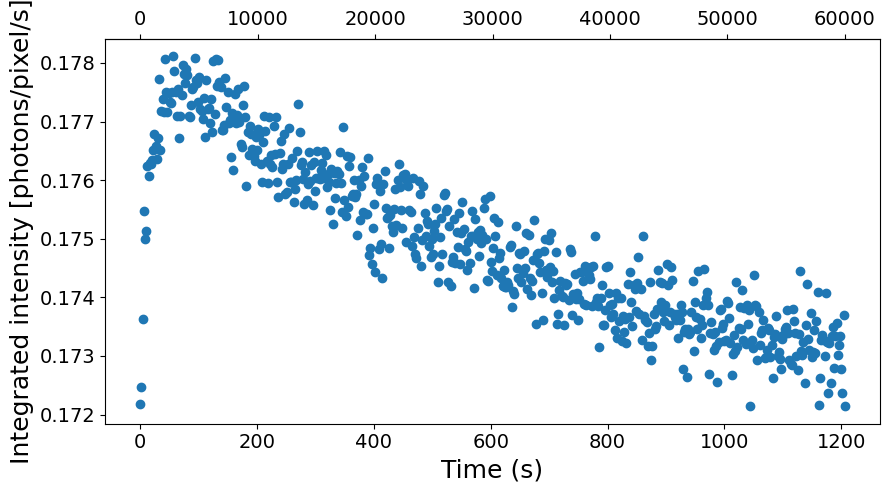

In [98]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 1.07 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 10.42 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.21 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.01 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,1.673148,0.1198,7.16018,0.640321,0.026504,4.139211,0.025642,0.000959,3.741114,1.001268,0.00003,0.002995,1.008229


/tmp/ipykernel_490053/3862425413.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


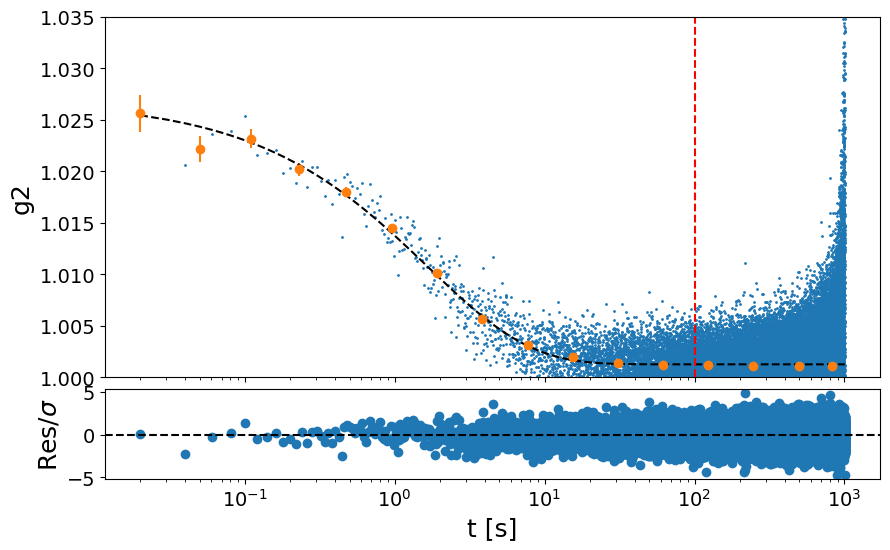

In [100]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

#  XPCS scan: T=520C, Q=0.19, 20min @ 20ms (60000fm) (GeO2_6, dataset 1, scan 1) 

In [101]:
#######################################
sample_name = 'GeO2_6_520C'
Ndataset = 1
Nscan = 1
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

Done! (elapsed time = 14.7 s)
Concatenating vectors ...
Done! (elapsed time = 0.52 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6_520C/GeO2_6_520C_0001/scan0001/
	 | Shape:       (59999, 523950)
	 | Sparsity:     3.4e-03
	 | Memory usage (scipy.csr_array): 1.180 GB (np.array usage: 117.110 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.59 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.02 s)


### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



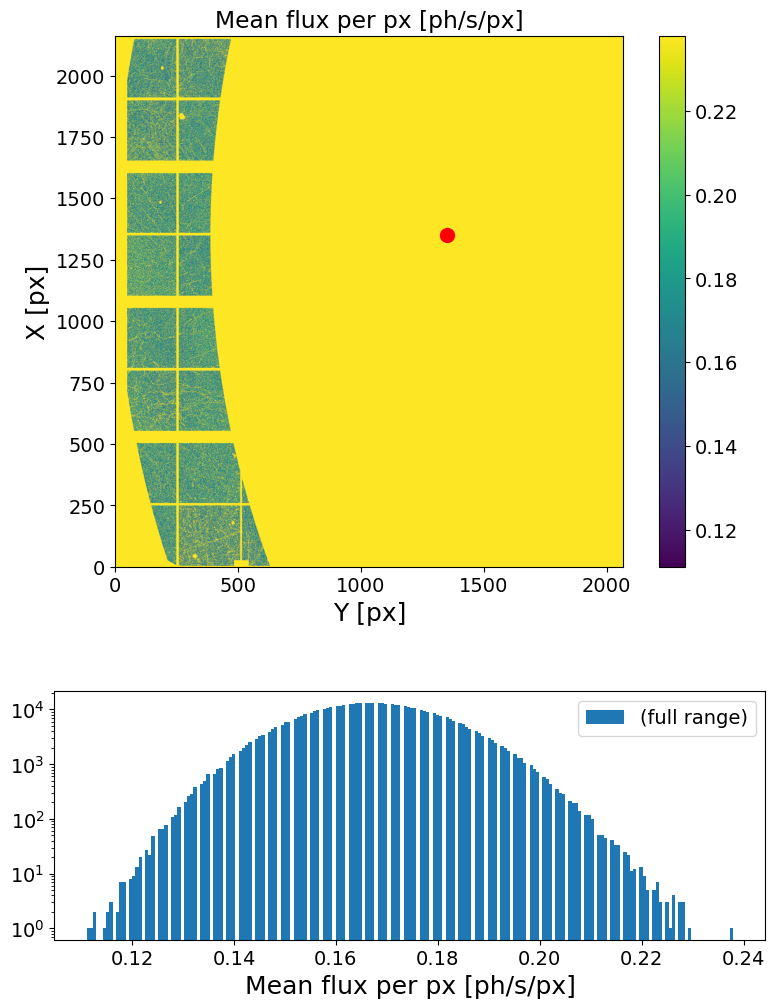

In [102]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [103]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

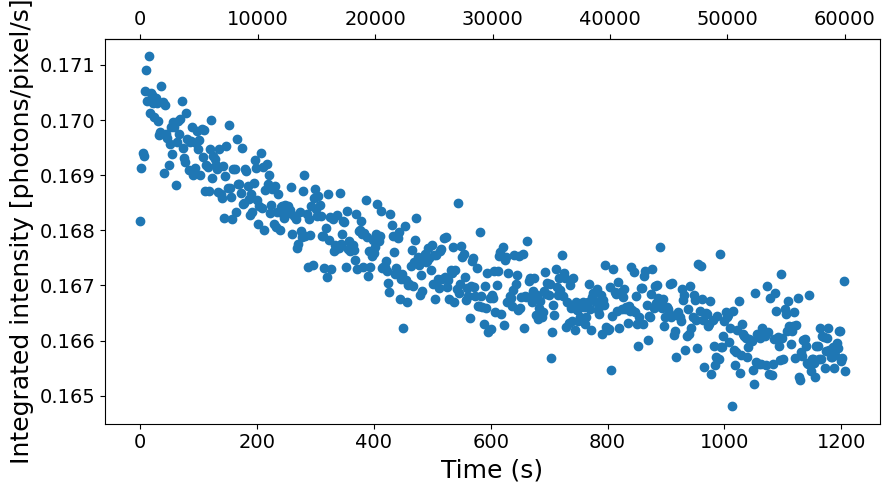

In [104]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 0.89 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 10.01 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.18 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.0 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,1.478519,0.121458,8.21483,0.650899,0.03143,4.82877,0.024325,0.001054,4.332386,1.001233,0.00003,0.003045,1.0065


/tmp/ipykernel_490053/3862425413.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


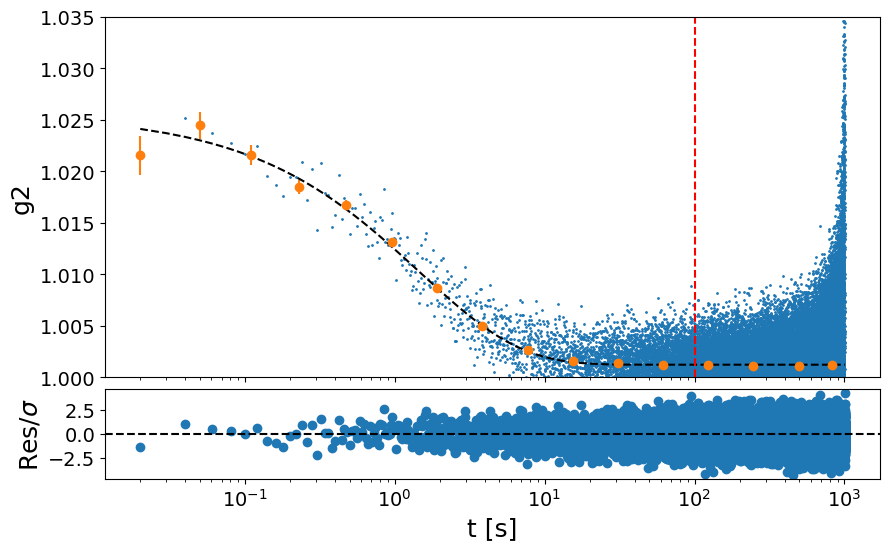

In [106]:
##################
t1_fit = None
t2_fit = 1e2
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=590C, Q=0.19, 20min @ 20ms (60000fm) (GeO2_6, dataset 1, scan 1) 

In [107]:
#######################################
sample_name = 'GeO2_6_590C'
Ndataset = 1
Nscan = 3
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

Done! (elapsed time = 15.35 s)
Concatenating vectors ...
Done! (elapsed time = 0.59 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6_590C/GeO2_6_590C_0001/scan0003/
	 | Shape:       (59999, 523950)
	 | Sparsity:     3.3e-03
	 | Memory usage (scipy.csr_array): 1.172 GB (np.array usage: 117.110 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.56 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.21 s)


### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



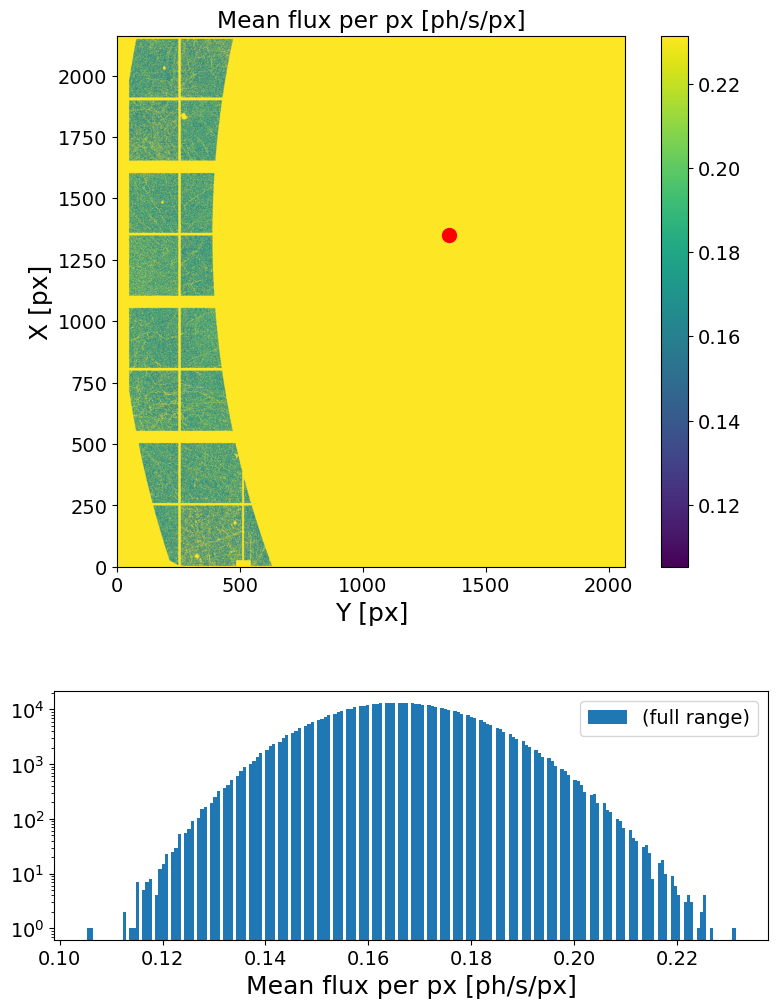

In [108]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [109]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

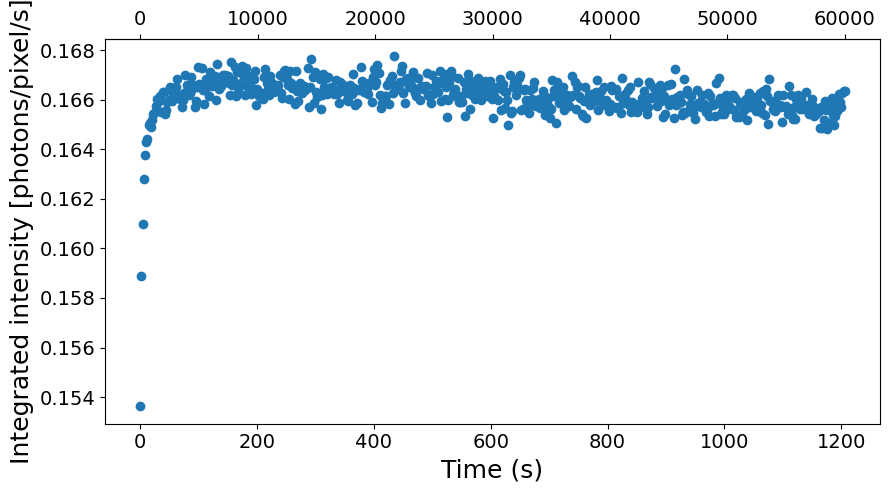

In [110]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [ ]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=15000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 1.17 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 11.64 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.62 s)

Computing g2 (using cython code)...
Done! (elapsed time = 2.56 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.608348,0.07641,12.560279,0.676219,0.051649,7.637969,0.024353,0.001666,6.842643,1.001275,0.00004,0.00401,0.955065


/tmp/ipykernel_490053/3681683624.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


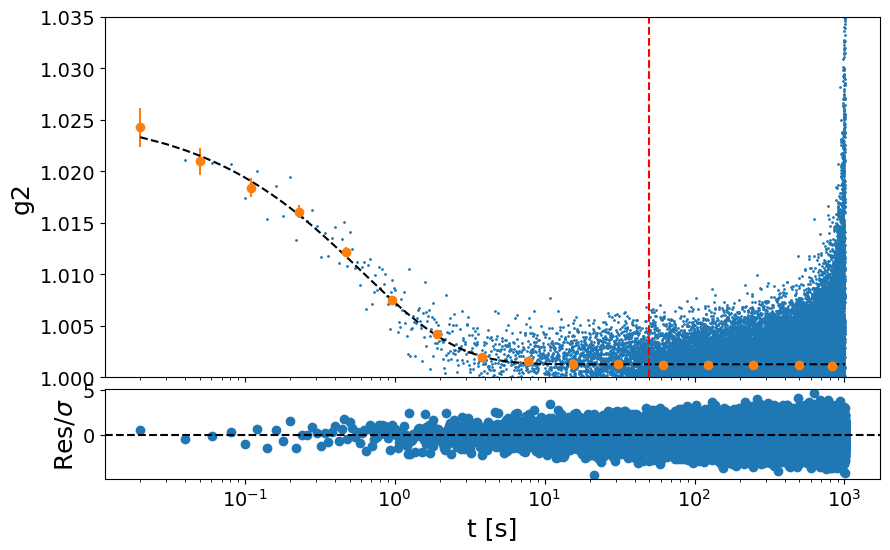

In [112]:
##################
t1_fit = None
t2_fit = 5e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=660C, Q=0.19, 20min @ 20ms (60000fm) (GeO2_6, dataset 1, scan 1)

In [113]:
#######################################
sample_name = 'GeO2_6_660C'
Ndataset = 1
Nscan = 1
Nfi, Nff = 1, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.02 1 60000
Ei = 9.699998837562536
itime = 0.020101
theta = 1.7500000000000004
Q = 0.15
T = 20.10 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/12 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/12 loo

Done! (elapsed time = 13.03 s)
Concatenating vectors ...
Done! (elapsed time = 0.43 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_6_660C/GeO2_6_660C_0001/scan0001/
	 | Shape:       (59999, 523950)
	 | Sparsity:     3.2e-03
	 | Memory usage (scipy.csr_array): 1.132 GB (np.array usage: 117.110 GB)
Filtering gamma ray signal (i.e. signals over treshold) ...
Done! (elapsed time = 0.55 s)
Removing gamma ray signal (set 0s) ...
Done! (elapsed time = 1.14 s)


### Flux check

################################################################################
Maximum count in the whole run -> 4.0
################################################################################



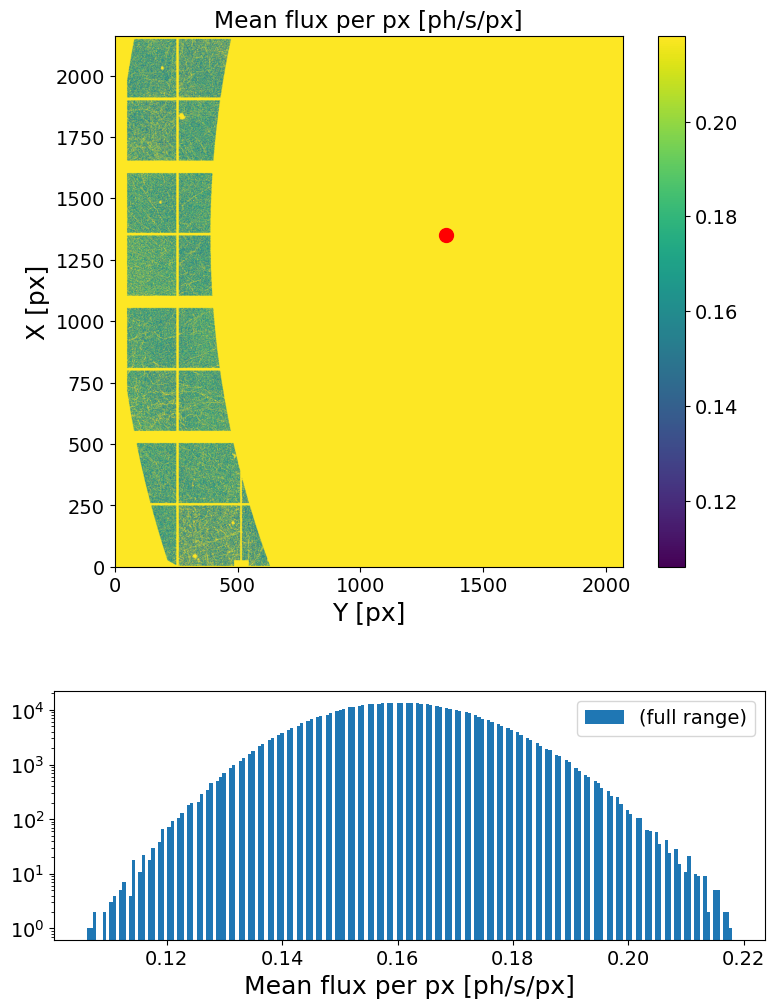

In [114]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [115]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

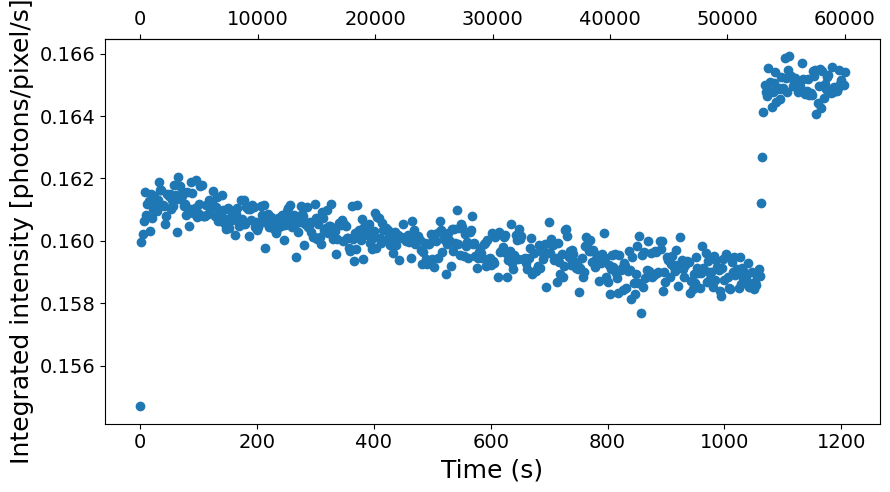

In [116]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [117]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=10000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 1.12 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 8.39 s)
	 | 49999 X 49999 squared matrix
	 | memory usage (np.array @ float32) = 9.313 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 1.5 s)

Computing g2 (using cython code)...
Done! (elapsed time = 3.08 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.242908,0.061482,25.310609,0.615932,0.07883,12.798451,0.026919,0.00354,13.15099,1.00117,0.000042,0.004192,1.055237


/tmp/ipykernel_490053/3681683624.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


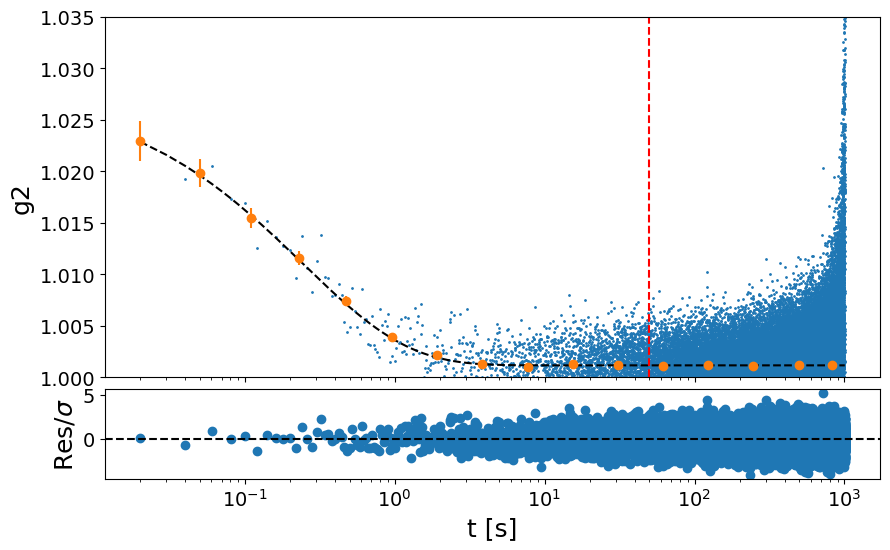

In [ ]:
##################
t1_fit = None
t2_fit = 5e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=730C, Q = 0.19, 7min @ 2ms (200000fm) (GeO2_6, dataset 1, scan 1) 

In [119]:
#######################################
sample_name = 'GeO2_6_730C'
Ndataset = 1
Nscan = 3
Nfi, Nff = 10, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.002 1 199804
Ei = 9.699998837562536
itime = 0.0021
theta = 1.7500000000000004
Q = 0.15
T = 6.99 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/40 loop

	 -> loading file eiger4m_v2_sparse_frame_0_00020.h5 (21/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00021.h5 (22/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00022.h5 (23/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00023.h5 (24/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00024.h5 (25/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00025.h5 (26/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00026.h5 (27/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00027.h5 (28/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00028.h5 (29/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00029.h5 (30/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00030.h5 (31/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00031.h5 (32/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00032.h5 (33/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00033.h5 (34/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00034.h5 (35/40 lo

### Flux check

################################################################################
Maximum count in the whole run -> 3.0
################################################################################



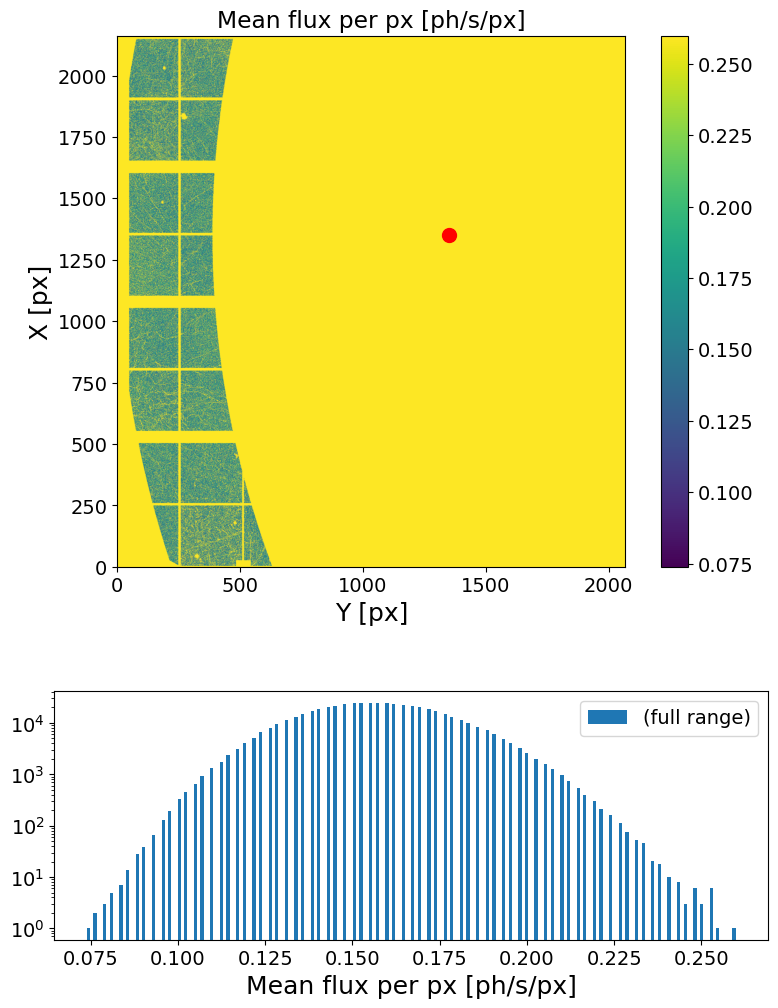

In [120]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [121]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

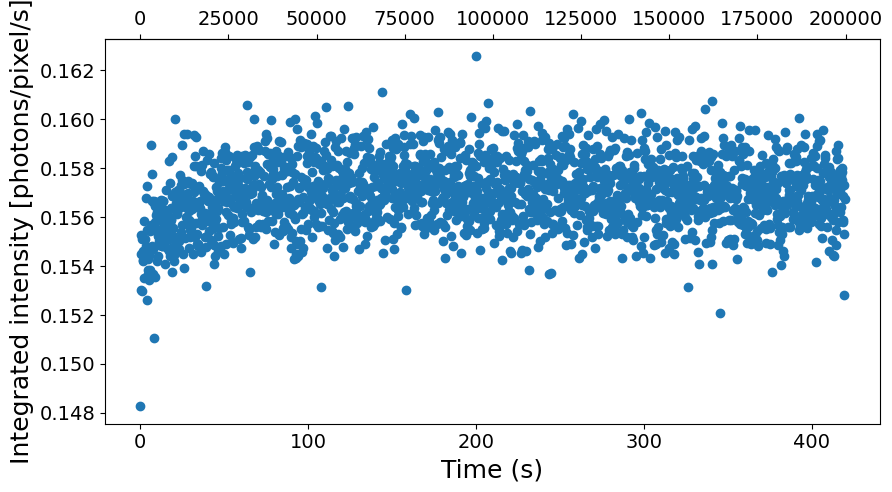

In [122]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [123]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=50000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...


Done! (elapsed time = 0.33 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 8.03 s)
	 | 149794 X 149794 squared matrix
	 | memory usage (np.array @ float32) = 83.589 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 8.33 s)

Computing g2 (using cython code)...
Done! (elapsed time = 17.43 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.058104,0.037355,64.289984,0.637545,0.224797,35.259736,0.032829,0.011013,33.547315,1.001076,0.000167,0.016713,1.001666


/tmp/ipykernel_490053/81207198.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


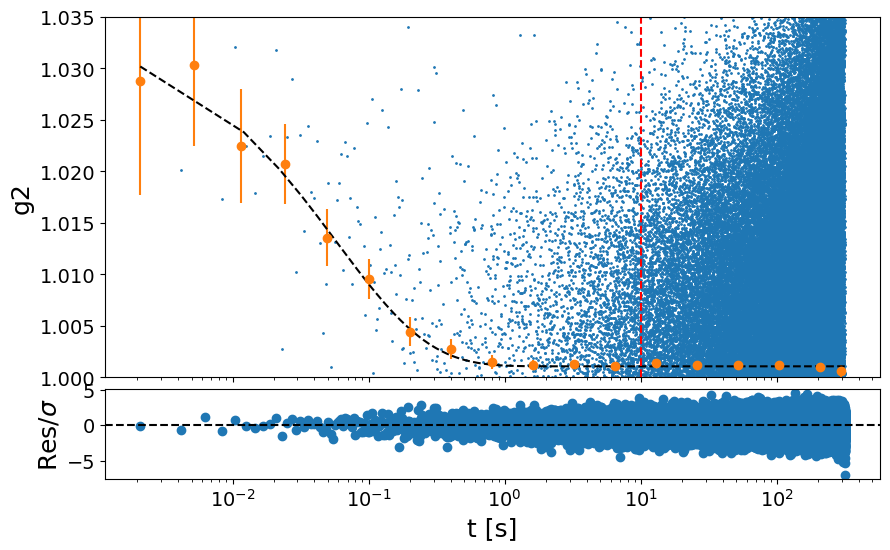

In [ ]:
##################
t1_fit = None
t2_fit = 1e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

#  XPCS scan: T=660C, Q=0.19, 7min @ 2ms (200000fm) (GeO2_6, dataset 2, scan 1) 

In [125]:
#######################################
sample_name = 'GeO2_6_660C'
Ndataset = 2
Nscan = 3
Nfi, Nff = None, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.002 1 199804
Ei = 9.699998837562536
itime = 0.0021
theta = 1.7500000000000004
Q = 0.15
T = 6.99 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/40 loop

### Flux check

################################################################################
Maximum count in the whole run -> 3.0
################################################################################



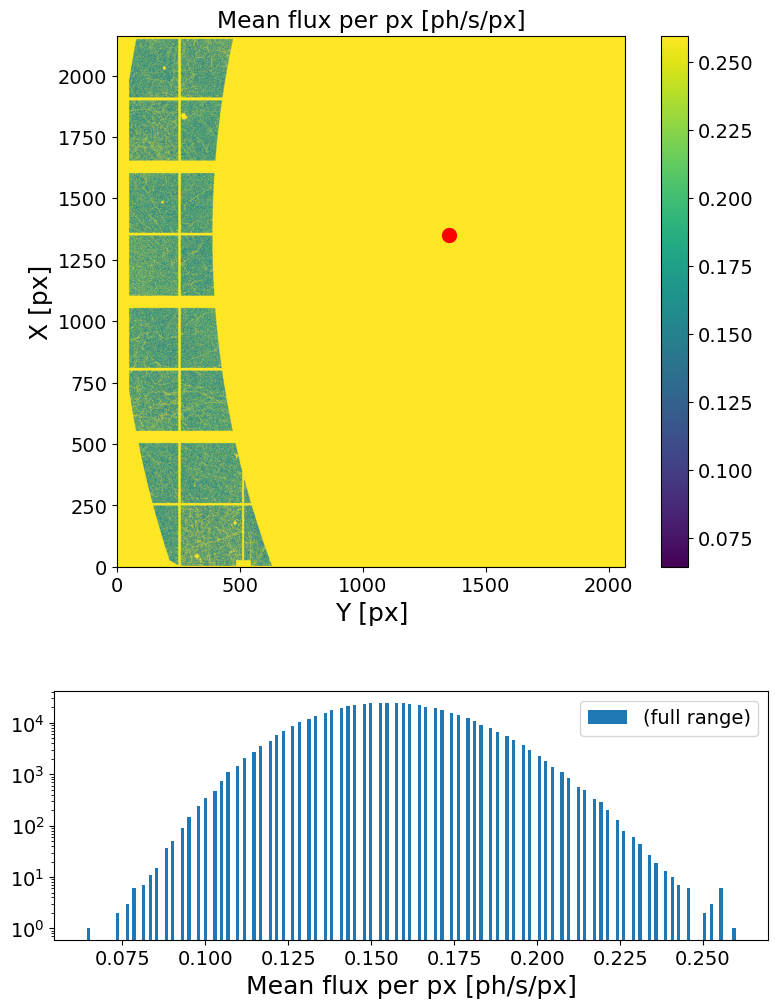

In [126]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [127]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

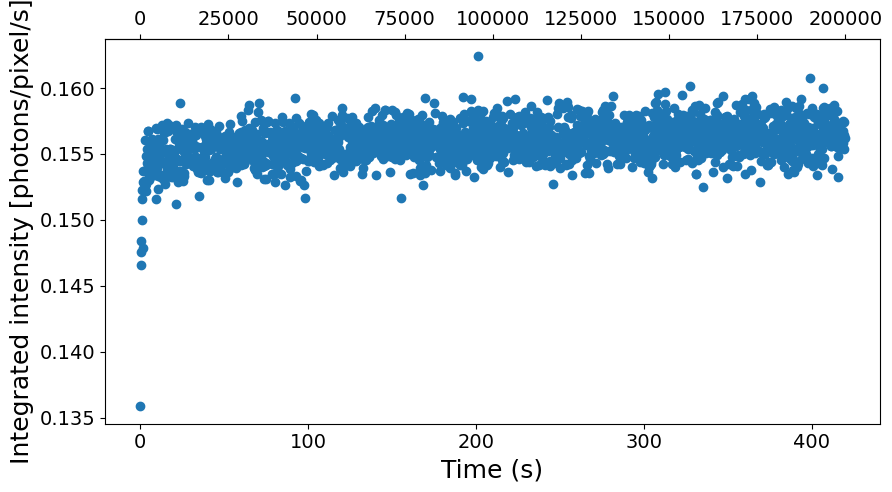

In [128]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [129]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=50000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.23 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 7.97 s)
	 | 149804 X 149804 squared matrix
	 | memory usage (np.array @ float32) = 83.6 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 8.42 s)

Computing g2 (using cython code)...
Done! (elapsed time = 17.35 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.08392,0.072376,86.24375,0.37875,0.083711,22.101893,0.036548,0.0116,31.739298,1.001103,0.000086,0.008633,0.992516


/tmp/ipykernel_490053/3681683624.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


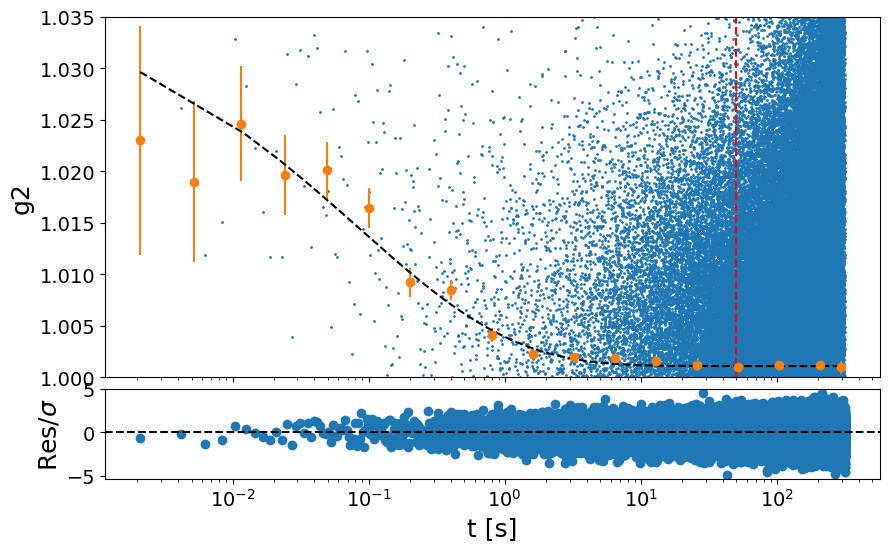

In [ ]:
##################
t1_fit = None
t2_fit = 5e1
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()

# XPCS scan: T=590C, Q=0.19, 7min @ 2ms (200000fm) (GeO2_6, dataset 2, scan 1) 

In [131]:
#######################################
sample_name = 'GeO2_6_590C'
Ndataset = 2
Nscan = 3
Nfi, Nff = 10, None
load_mask = e4m_mask * e4m_htmask * bs_mask * Qmask # Put None for profile analysis!
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=20, load_mask=load_mask)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.002 1 199804
Ei = 9.699998837562536
itime = 0.0021
theta = 1.7500000000000004
Q = 0.15
T = 6.99 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00009.h5 (10/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/40 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00011.h5 (12/40 loop

### Flux check

################################################################################
Maximum count in the whole run -> 3.0
################################################################################



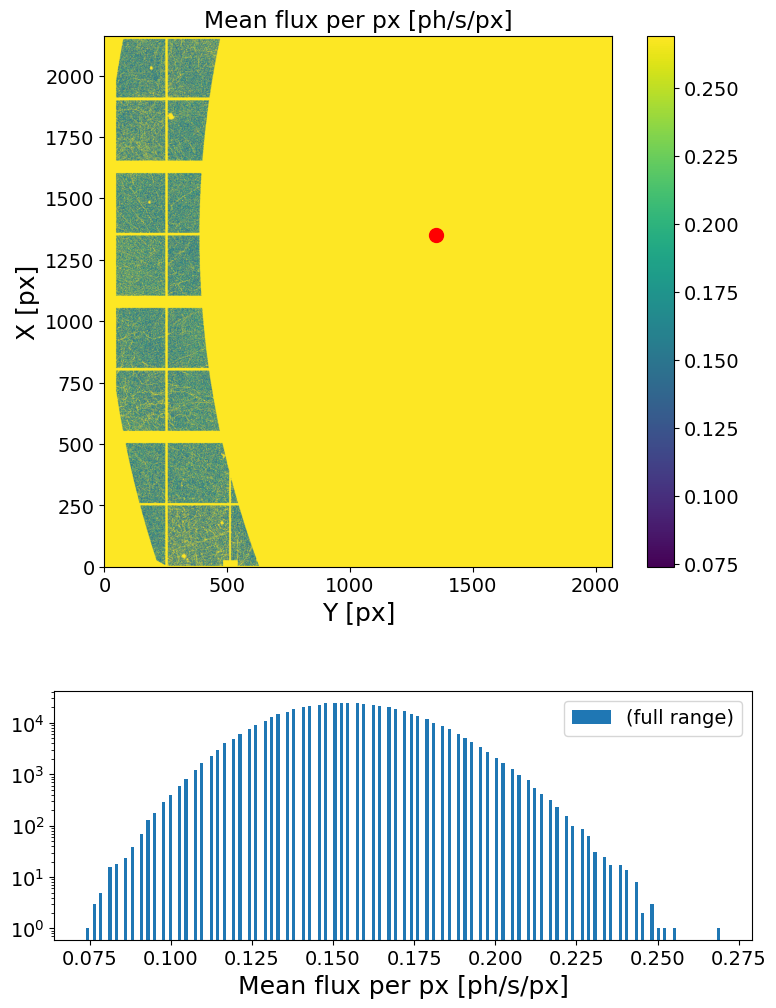

In [132]:
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=None, Ith_high=None, Nff=None, load_mask=load_mask)

### Intensity analysis

In [133]:
####################
Lbin = 100
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))
np.savetxt(f"{Intensity_folder}Idt-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", It)

<SecondaryAxis: >

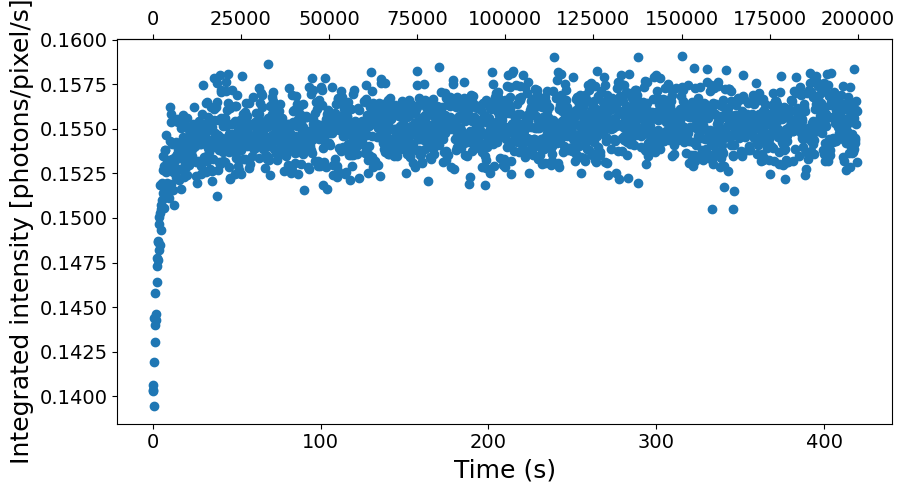

In [134]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Linear correlation of damaged-vGeO2

In [135]:
G2t = XPCS.get_G2t(e4m_data, mask=None, Nfi=50000, Nff=None, Lbin=None)

g2 = np.vstack(XPCS.get_g2(itime, G2t))
np.savetxt(f"{g24damaged_vGeO2_folder}g2-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", g2)

Loading frames ...
Done! (elapsed time = 0.23 s)
Computing G2t (using MKL library)...
Done! (elapsed time = 7.97 s)
	 | 149794 X 149794 squared matrix
	 | memory usage (np.array @ float32) = 83.589 GB
Normalizing G2t (using NumExpr library)...
Done! (elapsed time = 8.31 s)

Computing g2 (using cython code)...
Done! (elapsed time = 17.61 s)



Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan


,Q,dQ,tau,dtau,dtau%,beta,dbeta,dbeta%,c,dc,dc%,y0,dy0,dy%,redchi2
0,0.21,0.01,0.267633,0.105142,39.285955,0.467974,0.063988,13.673356,0.03424,0.005627,16.434091,1.001,0.000042,0.004204,0.997882


/tmp/ipykernel_490053/2695201314.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


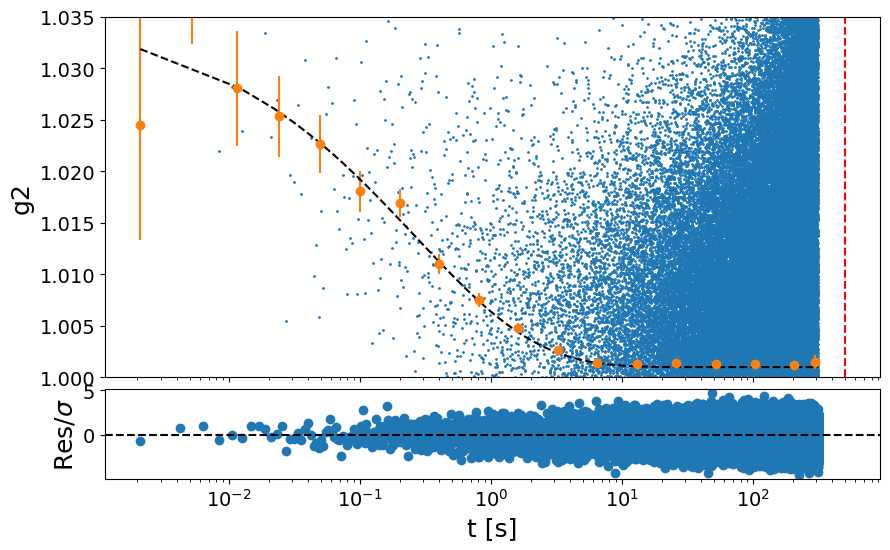

In [ ]:
##################
t1_fit = None
t2_fit = None
##################

################# KKW MODEL #################
model = lm.Model(decorrelation_f)
params = lm.Parameters()
params.add('tau', value=1, min=0, max=10)
params.add('beta', value=1, min=0, max=2)
params.add('c', value=.03, min=0, max=.1)
params.add('y0', value=1, min=1, max=1.01)
#params.add('y0', value=1.015, vary=False)
##############################################

fig, ax1, ax2 = plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=False)

ax1.set_ylim(1, 1.035)
plt.tight_layout(); plt.show()